# Old vs New Traction Pipeline Comparison

This notebook compares the archived pipeline results (`df_fin_reg.csv`, using `_gpt_ft` suffix)
against the new pipeline results (`df_fin.csv`) to identify deviations in
monetary/fiscal stance and agreement variables.

**Scope:** Stance & agreement variables only | Inner join on matched documents | Country-level analysis

**Sections:**
1. Merge & Coverage
2. Categorical Variable Comparison (exact match, confusion matrices)
3. Numeric Variable Comparison (MAE, correlation, distributions)
4. Country-Level Deviation Analysis
5. Disagreement Areas Text Comparison
6. Summary Dashboard

In [1]:
from pathlib import Path
import ast

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

import data_vis_utils as dv

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
OLD_PATH = Path("/data/home/xiong/data/Fund/CSR/Traction-archieve/output/df_fin_reg.csv")
NEW_PATH = Path("/data/home/xiong/data/Fund/CSR/Tractions/output/df_fin.csv")
OUTPUT_DIR = Path("/data/home/xiong/data/Fund/CSR/Tractions/output")
COUNTRY_META_PATH = Path("country_meta_info.xlsx")

# ── Column mapping: old name -> new name ────────────────────────────────────
# NOTE: In the old file, mon_agreement_gpt_ft / fis_agreement_gpt_ft are
# BINARY (0/1), not text.  They map to the new file's _bin columns.
# The text-valued agreement columns (mon_agreement, fis_agreement with labels
# like "mostly agree") are new-only and have no old equivalent.
# Similarly, mon_agreement_general_gpt_ft and fis_agreement_general_gpt_ft
# are binary in the old file -> map to _general_bin in the new file.
COLUMN_MAP = {
    # Monetary stance (text)
    "mon_stance_current_gpt_ft_staff": "mon_stance_current_staff",
    "mon_stance_future_gpt_ft_staff": "mon_stance_future_staff",
    "mon_stance_current_gpt_ft_buff": "mon_stance_current_buff",
    "mon_stance_future_gpt_ft_buff": "mon_stance_future_buff",
    # Monetary stance numeric
    "mon_stance_current_gpt_ft_staff_num": "mon_stance_current_staff_num",
    "mon_stance_current_gpt_ft_buff_num": "mon_stance_current_buff_num",
    "mon_stance_future_gpt_ft_staff_num": "mon_stance_future_staff_num",
    "mon_stance_future_gpt_ft_buff_num": "mon_stance_future_buff_num",
    # Monetary agreement (binary -> _bin)
    "mon_agreement_gpt_ft": "mon_agreement_bin",
    "mon_agreement_general_gpt_ft": "mon_agreement_general_bin",
    # Monetary agreement (text) -- these DO match between old and new
    "mon_agreement_stance_current_gpt_ft": "mon_agreement_stance_current",
    "mon_agreement_stance_current_gpt_ft_num": "mon_agreement_stance_current_num",
    "mon_agreement_stance_future_gpt_ft": "mon_agreement_stance_future",
    "mon_agreement_stance_future_gpt_ft_num": "mon_agreement_stance_future_num",
    "mon_agreement_stance_future_gpt_ft_cate1": "mon_agreement_stance_future_cate1",
    "mon_agreement_stance_future_gpt_ft_cate2": "mon_agreement_stance_future_cate2",
    # Monetary disagreement areas
    "mon_disagreement_areas_gpt_ft": "mon_disagreement_areas",
    # Fiscal stance (text)
    "fis_stance_near_term_gpt_ft_staff": "fis_stance_near_term_staff",
    "fis_stance_near_term_gpt_ft_buff": "fis_stance_near_term_buff",
    # Fiscal stance numeric
    "fis_stance_near_term_gpt_ft_staff_num": "fis_stance_near_term_staff_num",
    "fis_stance_near_term_gpt_ft_buff_num": "fis_stance_near_term_buff_num",
    # Fiscal agreement (binary -> _bin)
    "fis_agreement_gpt_ft": "fis_agreement_bin",
    "fis_agreement_general_gpt_ft": "fis_agreement_general_bin",
    # Fiscal agreement (text) -- these DO match between old and new
    "fis_agreement_stance_near_term_gpt_ft": "fis_agreement_stance_near_term",
    "fis_agreement_stance_near_term_gpt_ft_num": "fis_agreement_stance_near_term_num",
    "fis_agreement_stance_near_term_gpt_ft_cate1": "fis_agreement_stance_near_term_cate1",
    "fis_agreement_stance_near_term_gpt_ft_cate2": "fis_agreement_stance_near_term_cate2",
    # Fiscal disagreement areas
    "fis_disagreement_areas_gpt_ft": "fis_disagreement_areas",
}

# ── Variable groups (using NEW names) ─────────────────────────────────────────
CATEGORICAL_STANCE_COLS = [
    "mon_stance_current_staff", "mon_stance_current_buff",
    "mon_stance_future_staff", "mon_stance_future_buff",
    "fis_stance_near_term_staff", "fis_stance_near_term_buff",
]

CATEGORICAL_AGREEMENT_COLS = [
    # Text agreement columns that exist in both old and new
    "mon_agreement_stance_current", "mon_agreement_stance_future",
    "fis_agreement_stance_near_term",
]

CATEGORICAL_ORDINAL_COLS = [
    "mon_agreement_stance_future_cate1", "mon_agreement_stance_future_cate2",
    "fis_agreement_stance_near_term_cate1", "fis_agreement_stance_near_term_cate2",
]

NUMERIC_COLS = [
    "mon_stance_current_staff_num", "mon_stance_current_buff_num",
    "mon_stance_future_staff_num", "mon_stance_future_buff_num",
    "fis_stance_near_term_staff_num", "fis_stance_near_term_buff_num",
    "mon_agreement_stance_current_num", "mon_agreement_stance_future_num",
    "fis_agreement_stance_near_term_num",
    # Binary agreement columns (numeric 0/1)
    "mon_agreement_bin", "fis_agreement_bin",
    "mon_agreement_general_bin", "fis_agreement_general_bin",
]

OTHER_COLS = ["policy_mix_staff", "policy_mix_buff", "disagree_economic"]

ALL_COMPARE_COLS = (
    CATEGORICAL_STANCE_COLS + CATEGORICAL_AGREEMENT_COLS
    + CATEGORICAL_ORDINAL_COLS + NUMERIC_COLS + OTHER_COLS
)

# ── Colors ────────────────────────────────────────────────────────────────────
INCOME_GROUP_ORDER = ["AE", "EM", "LC"]
INCOME_COLORS = {"AE": "#2E5C8A", "EM": "#8EBDD6", "LC": "#2C9D5F"}
MATCH_COLORS = {"Match": "#2C9D5F", "Mismatch": "#E74C3C", "Both Missing": "#95A5A6"}

# Variable group labels for coloring bar charts
VAR_GROUP_MAP = {}
for c in CATEGORICAL_STANCE_COLS:
    VAR_GROUP_MAP[c] = "Stance (text)"
for c in CATEGORICAL_AGREEMENT_COLS:
    VAR_GROUP_MAP[c] = "Agreement (text)"
for c in CATEGORICAL_ORDINAL_COLS:
    VAR_GROUP_MAP[c] = "Ordinal"
for c in OTHER_COLS:
    VAR_GROUP_MAP[c] = "Other"

VAR_GROUP_COLORS = {
    "Stance (text)": "#1F77B4",
    "Agreement (text)": "#FF7F0E",
    "Ordinal": "#9467BD",
    "Other": "#8C564B",
}

In [3]:
# ── Load data ─────────────────────────────────────────────────────────────────
df_old_raw = pd.read_csv(OLD_PATH)
df_new = pd.read_csv(NEW_PATH)

print(f"Old: {df_old_raw.shape[0]} rows, {df_old_raw.shape[1]} cols")
print(f"New: {df_new.shape[0]} rows, {df_new.shape[1]} cols")

# Rename old columns to match new naming
df_old = df_old_raw.rename(columns=COLUMN_MAP).copy()

# Coerce year
df_old = dv.coerce_year_int(df_old)
df_new = dv.coerce_year_int(df_new)

# Add income_group to old file using country code
if "income_group" not in df_old.columns:
    df_old["income_group"] = df_old["Primary Country Code"].apply(
        dv.classify_income_group_from_code
    )

# Standardize country name column
if "country" in df_old.columns:
    df_old = df_old.rename(columns={"country": "country_name"})
if "Title" in df_new.columns:
    df_new = df_new.rename(columns={"Title": "country_name"})

print(f"\nOld year range: {df_old['year'].min()} - {df_old['year'].max()}")
print(f"New year range: {df_new['year'].min()} - {df_new['year'].max()}")

Old: 2064 rows, 214 cols
New: 981 rows, 43 cols

Old year range: 2014 - 2024
New year range: 2015 - 2023


## Section 1: Merge & Coverage

In [4]:
# ── Merge on Print ISBN (most precise identifier) ────────────────────────────
join_col = "Print ISBN"
isbn_overlap = set(df_old[join_col].dropna()) & set(df_new[join_col].dropna())
print(f"Print ISBN overlap: {len(isbn_overlap)} documents")
print(f"  Old unique ISBNs: {df_old[join_col].nunique()}")
print(f"  New unique ISBNs: {df_new[join_col].nunique()}")

# Use Print ISBN if overlap is decent; otherwise fallback to country+year
if len(isbn_overlap) > 0.5 * df_new[join_col].nunique():
    merge_keys = [join_col]
    print(f"\n-> Merging on: {merge_keys}")
else:
    merge_keys = ["Primary Country Code", "year"]
    print(f"\n-> ISBN overlap too low, merging on: {merge_keys}")

df_merged = df_old.merge(
    df_new, on=merge_keys, suffixes=("_old", "_new"), how="inner",
)

# Reconcile country/year columns from the merge
if "year_old" in df_merged.columns:
    df_merged["year"] = df_merged["year_old"].fillna(df_merged["year_new"])
if "Primary Country Code_old" in df_merged.columns:
    df_merged["Primary Country Code"] = df_merged["Primary Country Code_old"].fillna(
        df_merged["Primary Country Code_new"]
    )
if "income_group_old" in df_merged.columns:
    df_merged["income_group"] = df_merged["income_group_old"].fillna(
        df_merged["income_group_new"]
    )
if "country_name_old" in df_merged.columns:
    df_merged["country_name"] = df_merged["country_name_old"].fillna(
        df_merged["country_name_new"]
    )

# Ensure year is int
df_merged["year"] = pd.to_numeric(df_merged["year"], errors="coerce").astype("Int64")

print(f"\nMerged: {len(df_merged)} rows")
print(f"  Old rows not matched: {len(df_old) - len(df_merged)}")
print(f"  New rows not matched: {len(df_new) - len(df_merged)}")

Print ISBN overlap: 981 documents
  Old unique ISBNs: 981
  New unique ISBNs: 981

-> Merging on: ['Print ISBN']

Merged: 981 rows
  Old rows not matched: 1083
  New rows not matched: 0


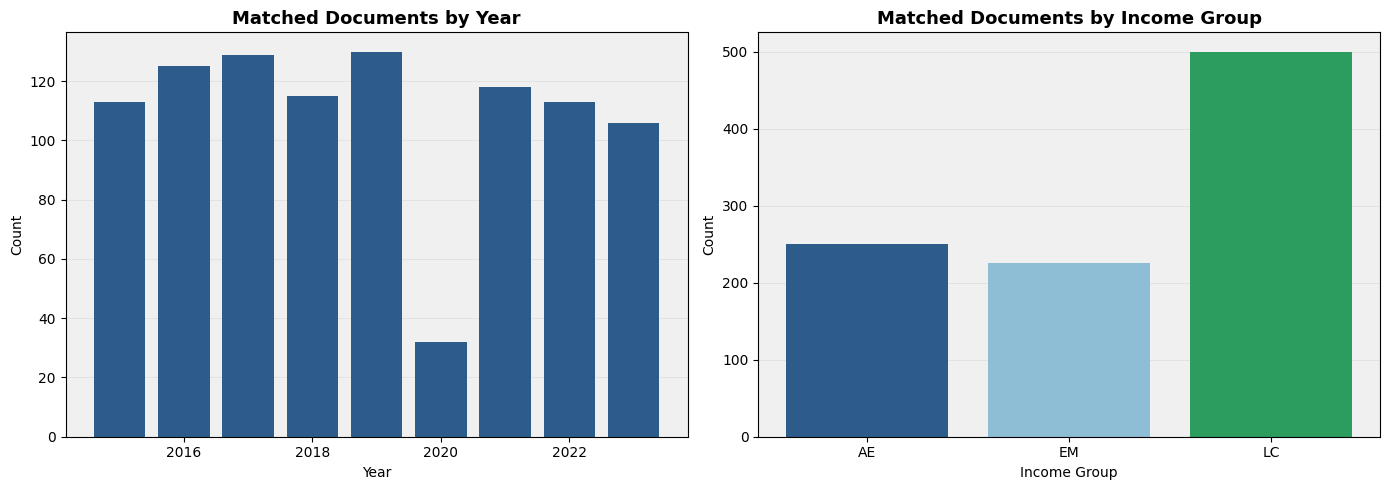


Coverage by year:
      count
year       
2015    113
2016    125
2017    129
2018    115
2019    130
2020     32
2021    118
2022    113
2023    106

Coverage by income group:
              count
income_group       
AE              250
EM              225
LC              500


In [5]:
# ── Coverage summary ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By year
yr_counts = df_merged.groupby("year").size()
axes[0].bar(yr_counts.index.astype(int), yr_counts.values, color="#2E5C8A")
axes[0].set_title("Matched Documents by Year", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")
dv.style_axes(axes[0])

# By income group
ig_counts = df_merged.groupby("income_group").size().reindex(INCOME_GROUP_ORDER, fill_value=0)
axes[1].bar(ig_counts.index, ig_counts.values,
            color=[INCOME_COLORS.get(g, "#999") for g in ig_counts.index])
axes[1].set_title("Matched Documents by Income Group", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Income Group")
axes[1].set_ylabel("Count")
dv.style_axes(axes[1])

plt.tight_layout()
plt.show()

print("\nCoverage by year:")
print(yr_counts.to_frame("count"))
print(f"\nCoverage by income group:")
print(ig_counts.to_frame("count"))

In [6]:
# ── Column availability check ────────────────────────────────────────────────
avail_rows = []
for col in ALL_COMPARE_COLS:
    col_old = f"{col}_old"
    col_new = f"{col}_new"
    in_old = col_old in df_merged.columns
    in_new = col_new in df_merged.columns
    n_old = df_merged[col_old].notna().sum() if in_old else 0
    n_new = df_merged[col_new].notna().sum() if in_new else 0
    avail_rows.append({
        "variable": col,
        "in_old": in_old,
        "in_new": in_new,
        "n_valid_old": n_old,
        "n_valid_new": n_new,
        "both_available": in_old and in_new,
    })

df_avail = pd.DataFrame(avail_rows)
print(f"Variables available in both: {df_avail['both_available'].sum()} / {len(df_avail)}")
display(df_avail.style.applymap(
    lambda v: "background-color: #d4edda" if v is True else
              ("background-color: #f8d7da" if v is False else ""),
    subset=["in_old", "in_new", "both_available"]
))

Variables available in both: 29 / 29


/tmp/ipykernel_3827265/3926489843.py:21: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(df_avail.style.applymap(


,variable,in_old,in_new,n_valid_old,n_valid_new,both_available
0,mon_stance_current_staff,True,True,981,807,True
1,mon_stance_current_buff,True,True,686,807,True
2,mon_stance_future_staff,True,True,686,807,True
3,mon_stance_future_buff,True,True,686,807,True
4,fis_stance_near_term_staff,True,True,976,971,True
5,fis_stance_near_term_buff,True,True,976,971,True
6,mon_agreement_stance_current,True,True,981,807,True
7,mon_agreement_stance_future,True,True,981,807,True
8,fis_agreement_stance_near_term,True,True,981,971,True
9,mon_agreement_stance_future_cate1,True,True,981,807,True


## Section 2: Categorical Variable Comparison

In [7]:
# ── Helper: compute match stats for a categorical column ─────────────────────
def compute_cat_match(df, col):
    """Compute exact match stats for a categorical column pair."""
    col_old, col_new = f"{col}_old", f"{col}_new"
    if col_old not in df.columns or col_new not in df.columns:
        return None

    # Normalize: strip, lowercase
    old_vals = df[col_old].astype(str).str.strip().str.lower().replace("nan", np.nan)
    new_vals = df[col_new].astype(str).str.strip().str.lower().replace("nan", np.nan)

    both_valid = old_vals.notna() & new_vals.notna()
    n_valid = both_valid.sum()
    if n_valid == 0:
        return {"variable": col, "n_valid": 0, "n_match": 0, "match_rate": np.nan}

    matches = (old_vals[both_valid] == new_vals[both_valid])
    return {
        "variable": col,
        "n_valid": int(n_valid),
        "n_match": int(matches.sum()),
        "match_rate": matches.mean() * 100,
    }


# Compute for all categorical + ordinal + other columns
cat_cols = CATEGORICAL_STANCE_COLS + CATEGORICAL_AGREEMENT_COLS + CATEGORICAL_ORDINAL_COLS + OTHER_COLS
cat_results = [r for r in (compute_cat_match(df_merged, c) for c in cat_cols) if r is not None]
df_cat_match = pd.DataFrame(cat_results).sort_values("match_rate")

print("Exact Match Rates for Categorical Variables (sorted ascending):")
display(df_cat_match.style.background_gradient(
    subset=["match_rate"], cmap="RdYlGn", vmin=0, vmax=100
).format({"match_rate": "{:.1f}%"}))

Exact Match Rates for Categorical Variables (sorted ascending):


,variable,n_valid,n_match,match_rate
12,fis_agreement_stance_near_term_cate2,971,629,64.8%
11,fis_agreement_stance_near_term_cate1,971,638,65.7%
14,policy_mix_buff,578,415,71.8%
10,mon_agreement_stance_future_cate2,807,580,71.9%
9,mon_agreement_stance_future_cate1,807,587,72.7%
8,fis_agreement_stance_near_term,971,718,73.9%
13,policy_mix_staff,619,461,74.5%
3,mon_stance_future_buff,670,504,75.2%
0,mon_stance_current_staff,807,610,75.6%
5,fis_stance_near_term_buff,966,738,76.4%


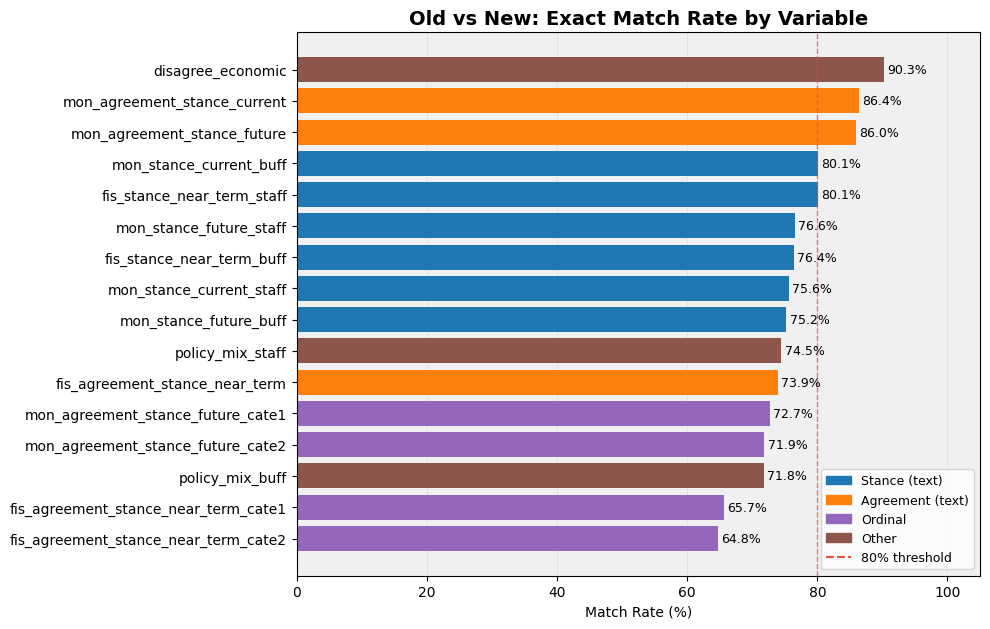

In [8]:
# ── Bar chart: match rates by variable ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, max(6, len(df_cat_match) * 0.4)))

colors = [VAR_GROUP_COLORS.get(VAR_GROUP_MAP.get(v, "Other"), "#999")
          for v in df_cat_match["variable"]]

bars = ax.barh(df_cat_match["variable"], df_cat_match["match_rate"], color=colors)
ax.axvline(x=80, color="#E74C3C", linestyle="--", linewidth=1, alpha=0.7, label="80% threshold")
ax.set_xlabel("Match Rate (%)")
ax.set_title("Old vs New: Exact Match Rate by Variable", fontsize=14, fontweight="bold")
ax.set_xlim(0, 105)

# Add legend for variable groups
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=g) for g, c in VAR_GROUP_COLORS.items()]
legend_handles.append(plt.Line2D([0], [0], color="#E74C3C", linestyle="--", label="80% threshold"))
ax.legend(handles=legend_handles, loc="lower right", fontsize=9)

# Annotate match rates on bars
for bar, rate in zip(bars, df_cat_match["match_rate"]):
    if not np.isnan(rate):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{rate:.1f}%", va="center", fontsize=9)

dv.style_axes(ax, grid=True, grid_axis="x")
plt.tight_layout()
plt.show()

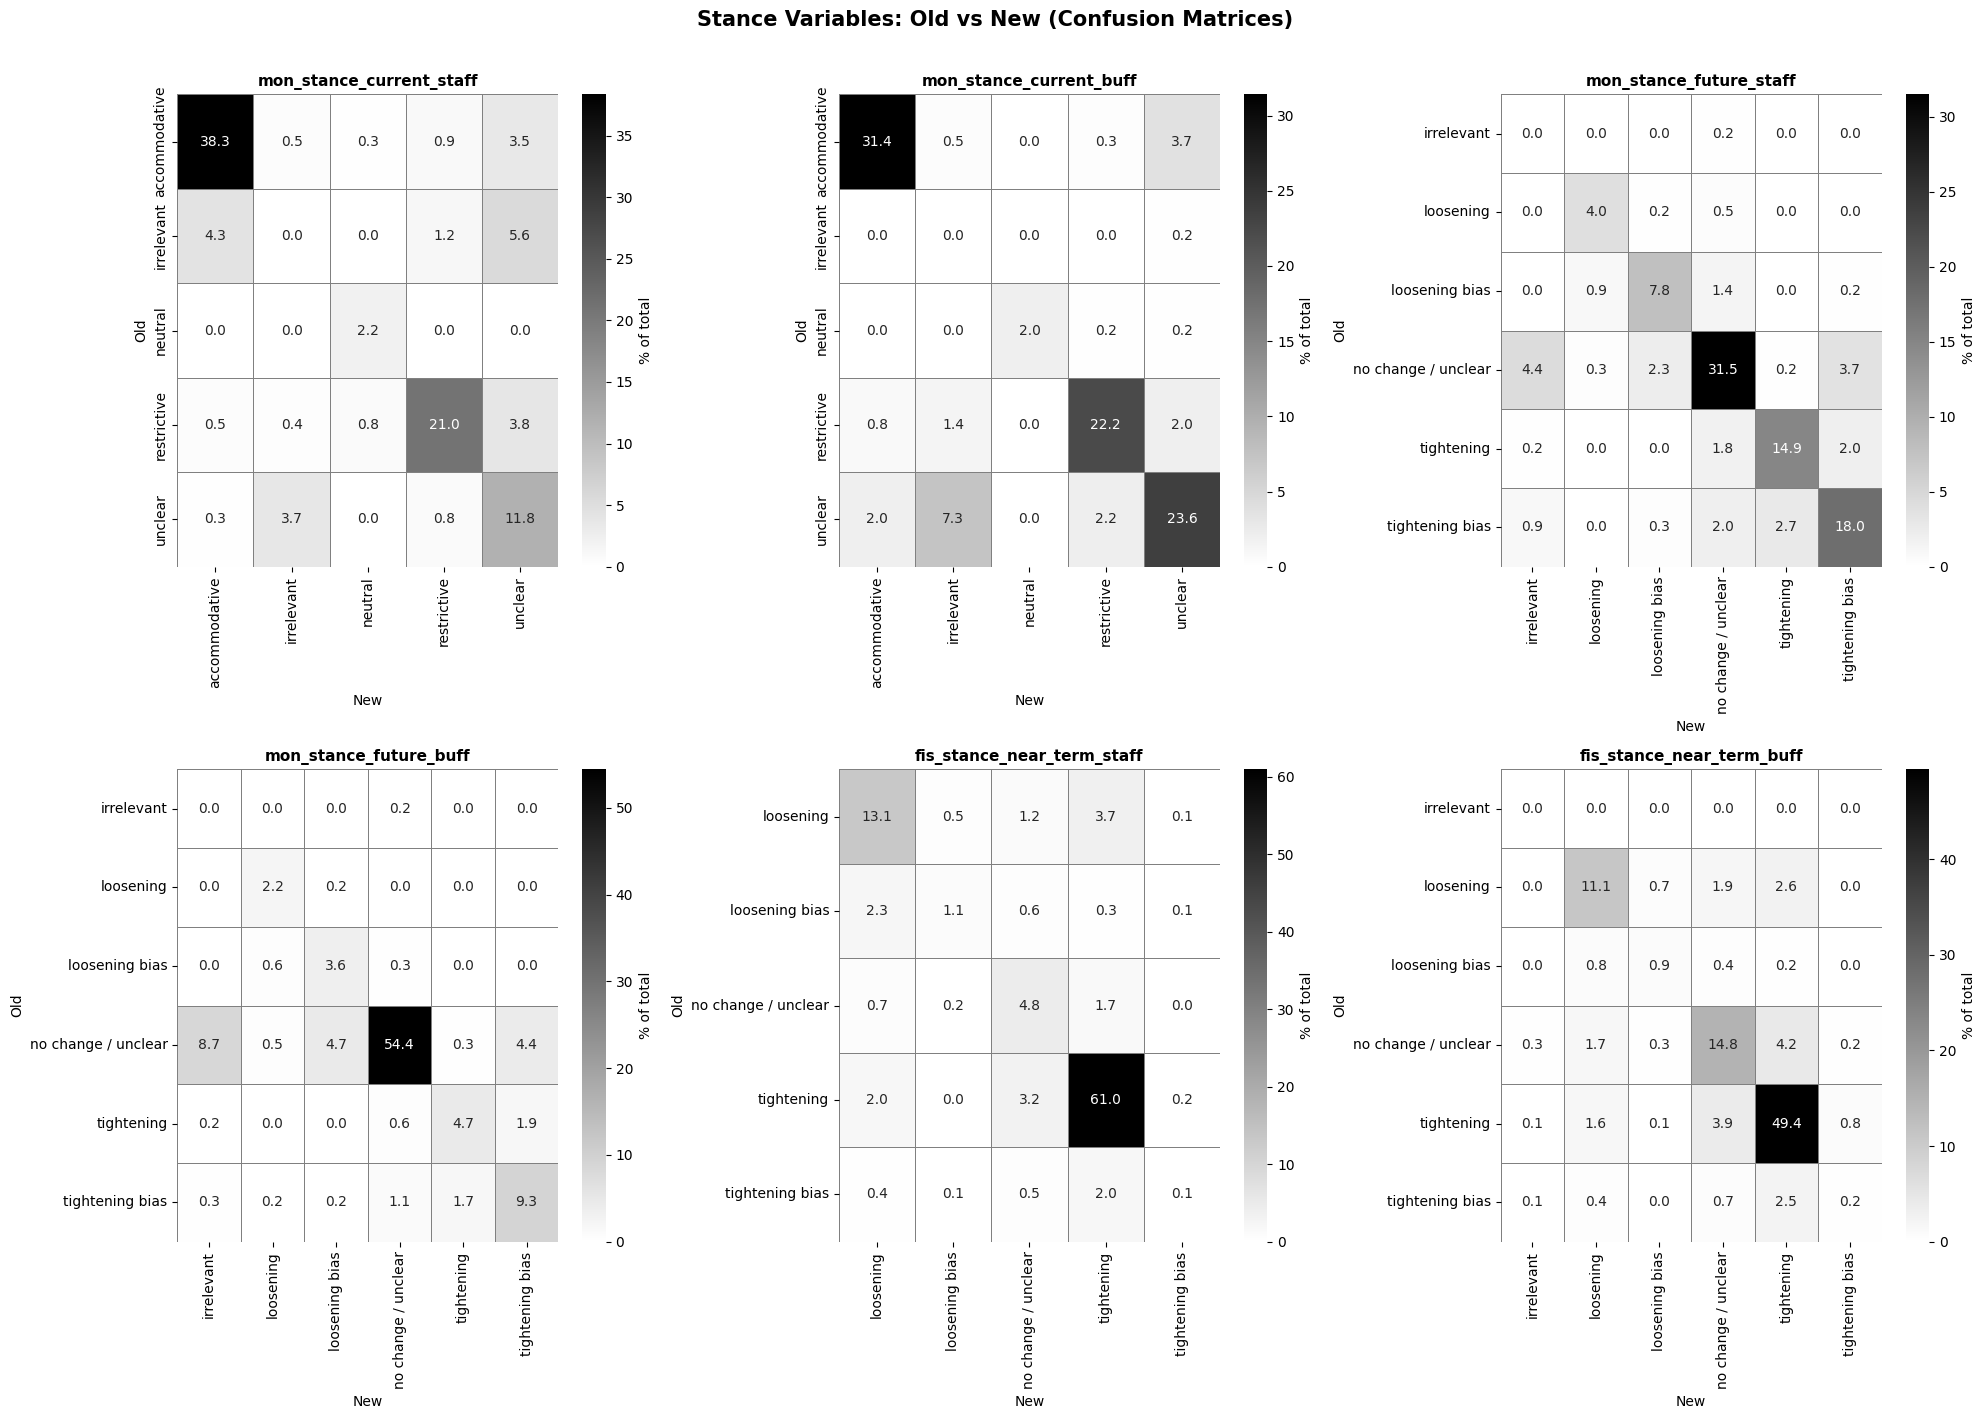

In [9]:
# ── Confusion matrices: 6 key stance variables ───────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 14))

for ax, col in zip(axes.flat, CATEGORICAL_STANCE_COLS):
    col_old, col_new = f"{col}_old", f"{col}_new"
    if col_old not in df_merged.columns or col_new not in df_merged.columns:
        ax.text(0.5, 0.5, f"{col}\nNot available", ha="center", va="center")
        continue

    sub = df_merged[[col_old, col_new]].dropna()
    old_norm = sub[col_old].astype(str).str.strip().str.lower()
    new_norm = sub[col_new].astype(str).str.strip().str.lower()

    # Filter out 'irrelevant' for cleaner matrices
    mask = (old_norm != "irrelevant") | (new_norm != "irrelevant")
    old_norm = old_norm[mask]
    new_norm = new_norm[mask]

    if len(old_norm) == 0:
        ax.text(0.5, 0.5, f"{col}\nNo valid pairs", ha="center", va="center")
        continue

    all_labels = sorted(set(old_norm) | set(new_norm))
    ct = pd.crosstab(old_norm, new_norm, normalize="all") * 100
    ct = ct.reindex(index=all_labels, columns=all_labels, fill_value=0)

    sns.heatmap(ct, annot=True, fmt=".1f", cmap="binary", ax=ax,
                linewidths=0.5, linecolor="grey", cbar_kws={"label": "% of total"})
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("New", fontsize=10)
    ax.set_ylabel("Old", fontsize=10)

plt.suptitle("Stance Variables: Old vs New (Confusion Matrices)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

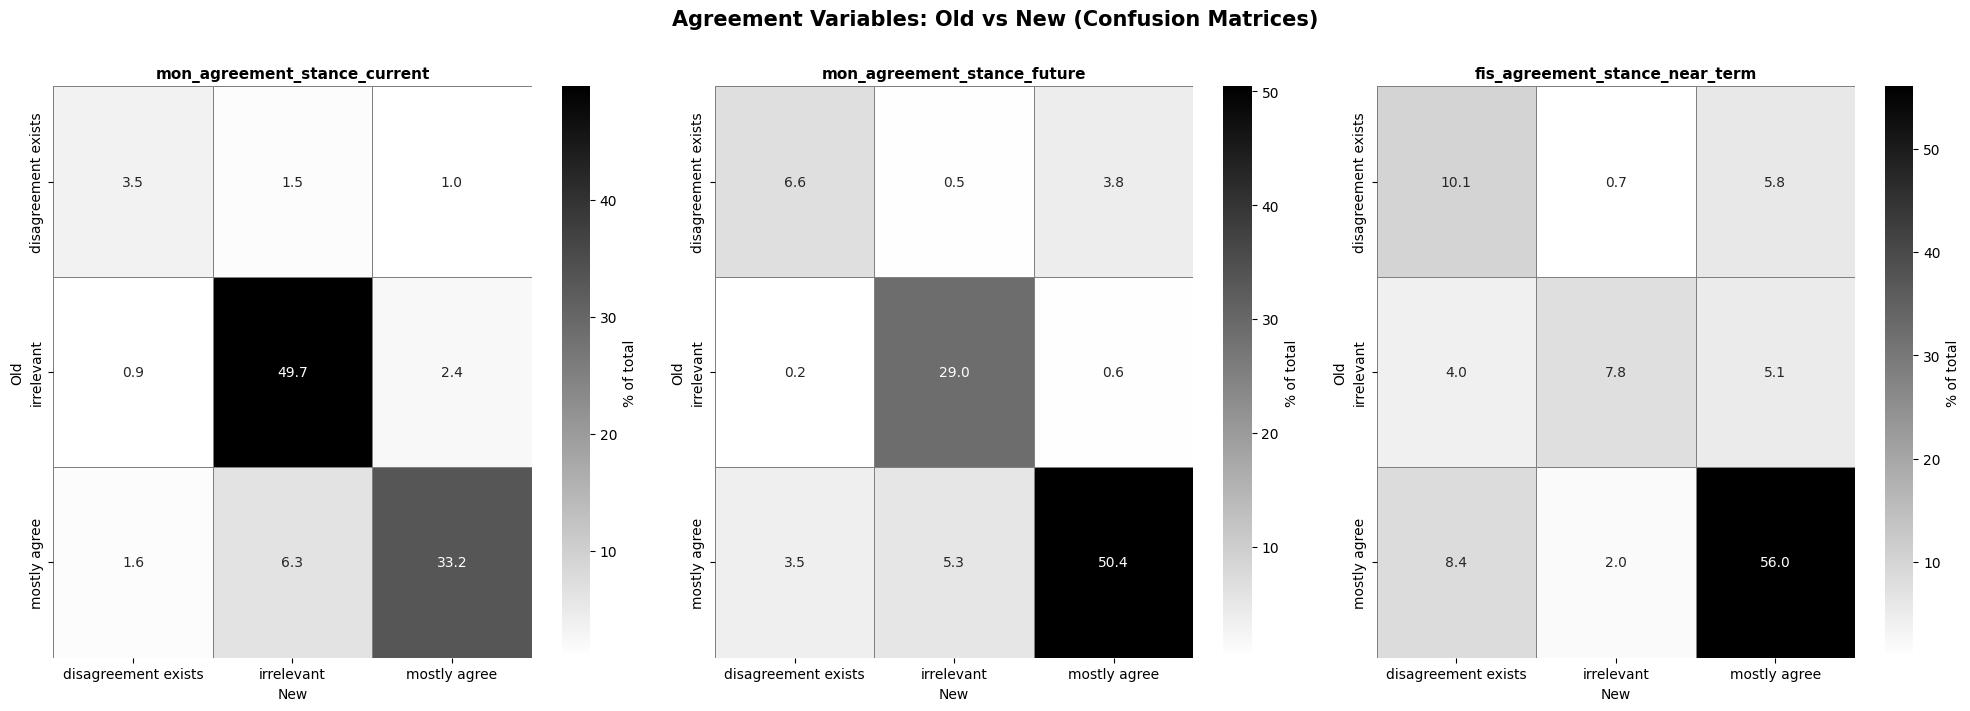

In [10]:
# ── Confusion matrices: agreement variables (text-valued) ────────────────────
agree_cols_for_cm = [
    "mon_agreement_stance_current", "mon_agreement_stance_future",
    "fis_agreement_stance_near_term",
]
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, col in zip(axes.flat, agree_cols_for_cm):
    col_old, col_new = f"{col}_old", f"{col}_new"
    if col_old not in df_merged.columns or col_new not in df_merged.columns:
        ax.text(0.5, 0.5, f"{col}\nNot available", ha="center", va="center")
        continue

    sub = df_merged[[col_old, col_new]].dropna()
    old_norm = sub[col_old].astype(str).str.strip().str.lower()
    new_norm = sub[col_new].astype(str).str.strip().str.lower()

    all_labels = sorted(set(old_norm) | set(new_norm))
    ct = pd.crosstab(old_norm, new_norm, normalize="all") * 100
    ct = ct.reindex(index=all_labels, columns=all_labels, fill_value=0)

    sns.heatmap(ct, annot=True, fmt=".1f", cmap="binary", ax=ax,
                linewidths=0.5, linecolor="grey", cbar_kws={"label": "% of total"})
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("New", fontsize=10)
    ax.set_ylabel("Old", fontsize=10)

plt.suptitle("Agreement Variables: Old vs New (Confusion Matrices)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

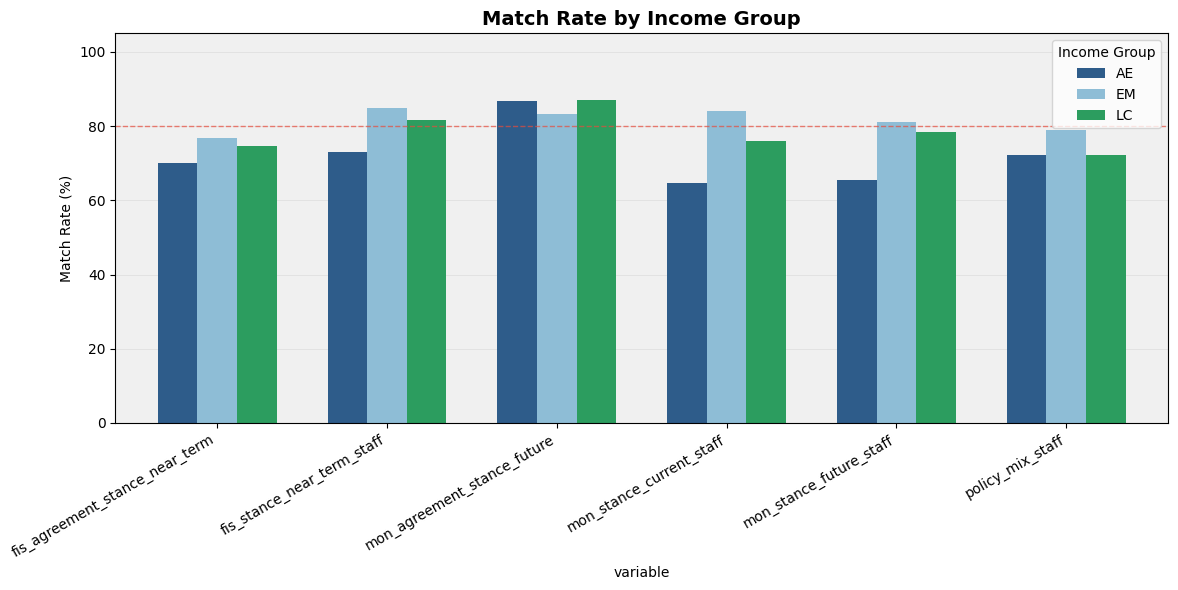

In [11]:
# ── Match rate by income group ───────────────────────────────────────────────
# key_cat_cols: categorical text columns used for key comparisons throughout
key_cat_cols = [
    "mon_stance_future_staff", "mon_stance_current_staff",
    "fis_stance_near_term_staff",
    "mon_agreement_stance_future", "fis_agreement_stance_near_term",
    "policy_mix_staff",
]

ig_match_rows = []
for col in key_cat_cols:
    col_old, col_new = f"{col}_old", f"{col}_new"
    if col_old not in df_merged.columns or col_new not in df_merged.columns:
        continue
    for ig in INCOME_GROUP_ORDER:
        sub = df_merged[df_merged["income_group"] == ig]
        old_v = sub[col_old].astype(str).str.strip().str.lower().replace("nan", np.nan)
        new_v = sub[col_new].astype(str).str.strip().str.lower().replace("nan", np.nan)
        valid = old_v.notna() & new_v.notna()
        n = valid.sum()
        match_rate = (old_v[valid] == new_v[valid]).mean() * 100 if n > 0 else np.nan
        ig_match_rows.append({"variable": col, "income_group": ig, "match_rate": match_rate, "n": n})

df_ig_match = pd.DataFrame(ig_match_rows)

fig, ax = plt.subplots(figsize=(12, 6))
pivot = df_ig_match.pivot(index="variable", columns="income_group", values="match_rate")
pivot = pivot.reindex(columns=INCOME_GROUP_ORDER)
pivot.plot.bar(ax=ax, color=[INCOME_COLORS[g] for g in INCOME_GROUP_ORDER], width=0.7)
ax.set_ylabel("Match Rate (%)")
ax.set_title("Match Rate by Income Group", fontsize=14, fontweight="bold")
ax.set_ylim(0, 105)
ax.axhline(y=80, color="#E74C3C", linestyle="--", linewidth=1, alpha=0.7)
ax.legend(title="Income Group")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
dv.style_axes(ax)
plt.tight_layout()
plt.show()

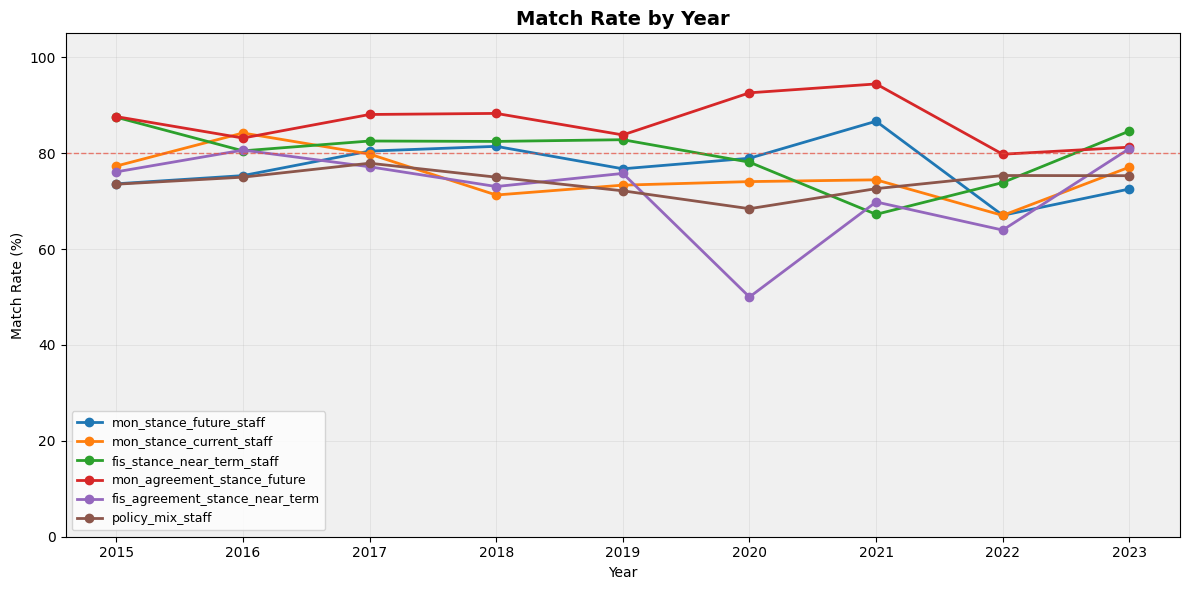

In [12]:
# ── Match rate by year ───────────────────────────────────────────────────────
yr_match_rows = []
for col in key_cat_cols:
    col_old, col_new = f"{col}_old", f"{col}_new"
    if col_old not in df_merged.columns or col_new not in df_merged.columns:
        continue
    for yr in sorted(df_merged["year"].dropna().unique()):
        sub = df_merged[df_merged["year"] == yr]
        old_v = sub[col_old].astype(str).str.strip().str.lower().replace("nan", np.nan)
        new_v = sub[col_new].astype(str).str.strip().str.lower().replace("nan", np.nan)
        valid = old_v.notna() & new_v.notna()
        n = valid.sum()
        match_rate = (old_v[valid] == new_v[valid]).mean() * 100 if n > 0 else np.nan
        yr_match_rows.append({"variable": col, "year": int(yr), "match_rate": match_rate})

df_yr_match = pd.DataFrame(yr_match_rows)

fig, ax = plt.subplots(figsize=(12, 6))
for col in key_cat_cols:
    sub = df_yr_match[df_yr_match["variable"] == col]
    if sub.empty:
        continue
    ax.plot(sub["year"], sub["match_rate"], marker="o", linewidth=2, label=col)

ax.set_xlabel("Year")
ax.set_ylabel("Match Rate (%)")
ax.set_title("Match Rate by Year", fontsize=14, fontweight="bold")
ax.set_ylim(0, 105)
ax.axhline(y=80, color="#E74C3C", linestyle="--", linewidth=1, alpha=0.7)
ax.legend(loc="lower left", fontsize=9)
dv.style_axes(ax, grid=True, grid_axis="both")
plt.tight_layout()
plt.show()

In [13]:
# ── Transition analysis: most common label changes for mismatches ────────────
print("Most Frequent Label Transitions (Old -> New) for Mismatches:\n")

for col in key_cat_cols:
    col_old, col_new = f"{col}_old", f"{col}_new"
    if col_old not in df_merged.columns or col_new not in df_merged.columns:
        continue

    old_v = df_merged[col_old].astype(str).str.strip().str.lower().replace("nan", np.nan)
    new_v = df_merged[col_new].astype(str).str.strip().str.lower().replace("nan", np.nan)
    valid = old_v.notna() & new_v.notna()
    mismatched = valid & (old_v != new_v)

    if mismatched.sum() == 0:
        print(f"  {col}: No mismatches!")
        continue

    transitions = pd.DataFrame({
        "old": old_v[mismatched], "new": new_v[mismatched]
    })
    top_trans = (transitions.groupby(["old", "new"]).size()
                .reset_index(name="count")
                .sort_values("count", ascending=False)
                .head(5))
    top_trans["pct_of_mismatches"] = (top_trans["count"] / mismatched.sum() * 100).round(1)

    print(f"  {col} ({mismatched.sum()} mismatches out of {valid.sum()} valid):")
    for _, row in top_trans.iterrows():
        print(f"    {row['old']} -> {row['new']}  |  {row['count']}  ({row['pct_of_mismatches']}%)")
    print()

Most Frequent Label Transitions (Old -> New) for Mismatches:

  mon_stance_future_staff (157 mismatches out of 670 valid):
    no change / unclear -> irrelevant  |  29  (18.5%)
    no change / unclear -> tightening bias  |  24  (15.3%)
    tightening bias -> tightening  |  18  (11.5%)
    no change / unclear -> loosening bias  |  15  (9.6%)
    tightening -> tightening bias  |  13  (8.3%)

  mon_stance_current_staff (197 mismatches out of 807 valid):
    irrelevant -> unclear  |  41  (20.8%)
    irrelevant -> accommodative  |  32  (16.2%)
    restrictive -> unclear  |  28  (14.2%)
    unclear -> irrelevant  |  27  (13.7%)
    accommodative -> unclear  |  26  (13.2%)

  fis_stance_near_term_staff (192 mismatches out of 966 valid):
    loosening -> tightening  |  36  (18.8%)
    tightening -> no change / unclear  |  31  (16.1%)
    loosening bias -> loosening  |  22  (11.5%)
    tightening -> loosening  |  19  (9.9%)
    tightening bias -> tightening  |  19  (9.9%)

  mon_agreement_stanc

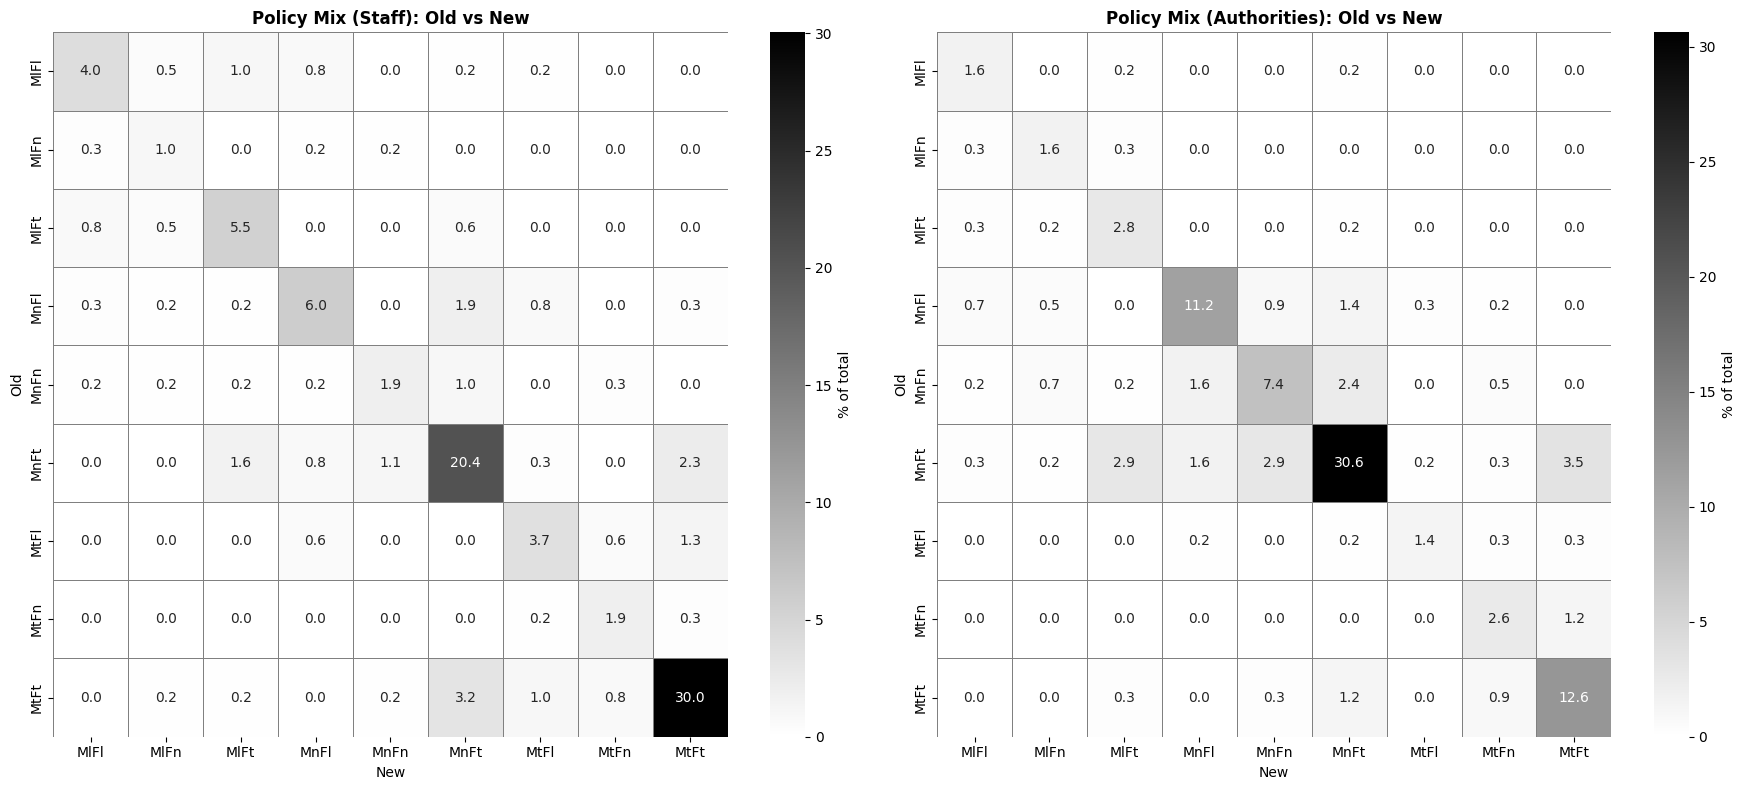

In [14]:
# ── Policy mix confusion matrices ────────────────────────────────────────────
POLICY_MIX_ORDER = [
    "MtFt", "MtFn", "MtFl",
    "MnFt", "MnFn", "MnFl",
    "MlFt", "MlFn", "MlFl",
]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, col, title in zip(axes,
    ["policy_mix_staff", "policy_mix_buff"],
    ["Policy Mix (Staff): Old vs New", "Policy Mix (Authorities): Old vs New"]):

    col_old, col_new = f"{col}_old", f"{col}_new"
    if col_old not in df_merged.columns or col_new not in df_merged.columns:
        ax.text(0.5, 0.5, f"{col}\nNot available", ha="center", va="center")
        continue

    sub = df_merged[[col_old, col_new]].dropna()
    if len(sub) == 0:
        ax.text(0.5, 0.5, f"{col}\nNo valid pairs", ha="center", va="center")
        continue

    ct = pd.crosstab(sub[col_old], sub[col_new], normalize="all") * 100
    present_labels = sorted(set(ct.index) | set(ct.columns))
    ct = ct.reindex(index=present_labels, columns=present_labels, fill_value=0)

    sns.heatmap(ct, annot=True, fmt=".1f", cmap="binary", ax=ax,
                linewidths=0.5, linecolor="grey", cbar_kws={"label": "% of total"})
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("New")
    ax.set_ylabel("Old")

plt.tight_layout()
plt.show()

## Section 3: Numeric Variable Comparison

In [15]:
# ── Summary stats for all numeric column pairs ───────────────────────────────
num_results = []
for col in NUMERIC_COLS:
    col_old, col_new = f"{col}_old", f"{col}_new"
    if col_old not in df_merged.columns or col_new not in df_merged.columns:
        continue

    old_v = pd.to_numeric(df_merged[col_old], errors="coerce")
    new_v = pd.to_numeric(df_merged[col_new], errors="coerce")
    valid = old_v.notna() & new_v.notna()
    n = valid.sum()

    if n == 0:
        num_results.append({"variable": col, "n_valid": 0})
        continue

    diff = new_v[valid] - old_v[valid]
    num_results.append({
        "variable": col,
        "n_valid": int(n),
        "mean_old": old_v[valid].mean(),
        "mean_new": new_v[valid].mean(),
        "mean_diff": diff.mean(),
        "mae": diff.abs().mean(),
        "rmse": np.sqrt((diff**2).mean()),
        "correlation": old_v[valid].corr(new_v[valid]),
        "exact_match_pct": (diff == 0).mean() * 100,
    })

df_num_stats = pd.DataFrame(num_results)
print("Numeric Variable Summary Statistics:")
display(df_num_stats.style.format({
    "mean_old": "{:.3f}", "mean_new": "{:.3f}", "mean_diff": "{:.3f}",
    "mae": "{:.3f}", "rmse": "{:.3f}", "correlation": "{:.3f}",
    "exact_match_pct": "{:.1f}%",
}).background_gradient(subset=["correlation"], cmap="RdYlGn", vmin=0, vmax=1))

Numeric Variable Summary Statistics:


,variable,n_valid,mean_old,mean_new,mean_diff,mae,rmse,correlation,exact_match_pct
0,mon_stance_current_staff_num,473,0.732,0.736,0.004,0.063,0.332,0.938,96.0%
1,mon_stance_current_buff_num,366,0.847,0.833,-0.014,0.041,0.281,0.958,97.8%
2,mon_stance_future_staff_num,589,3.457,3.433,-0.024,0.231,0.544,0.877,80.1%
3,mon_stance_future_buff_num,540,3.209,3.161,-0.048,0.219,0.516,0.808,80.4%
4,fis_stance_near_term_staff_num,942,3.958,4.004,0.047,0.444,1.149,0.746,81.1%
5,fis_stance_near_term_buff_num,793,3.963,4.005,0.042,0.425,1.099,0.759,80.6%
6,mon_agreement_stance_current_num,317,-0.095,-0.091,0.003,0.117,0.460,0.680,93.1%
7,mon_agreement_stance_future_num,519,0.258,0.291,0.033,0.399,0.738,0.724,66.7%
8,fis_agreement_stance_near_term_num,780,0.096,0.133,0.037,0.745,1.569,0.476,69.7%
9,mon_agreement_bin,578,0.869,0.836,-0.033,0.067,0.260,0.739,93.3%


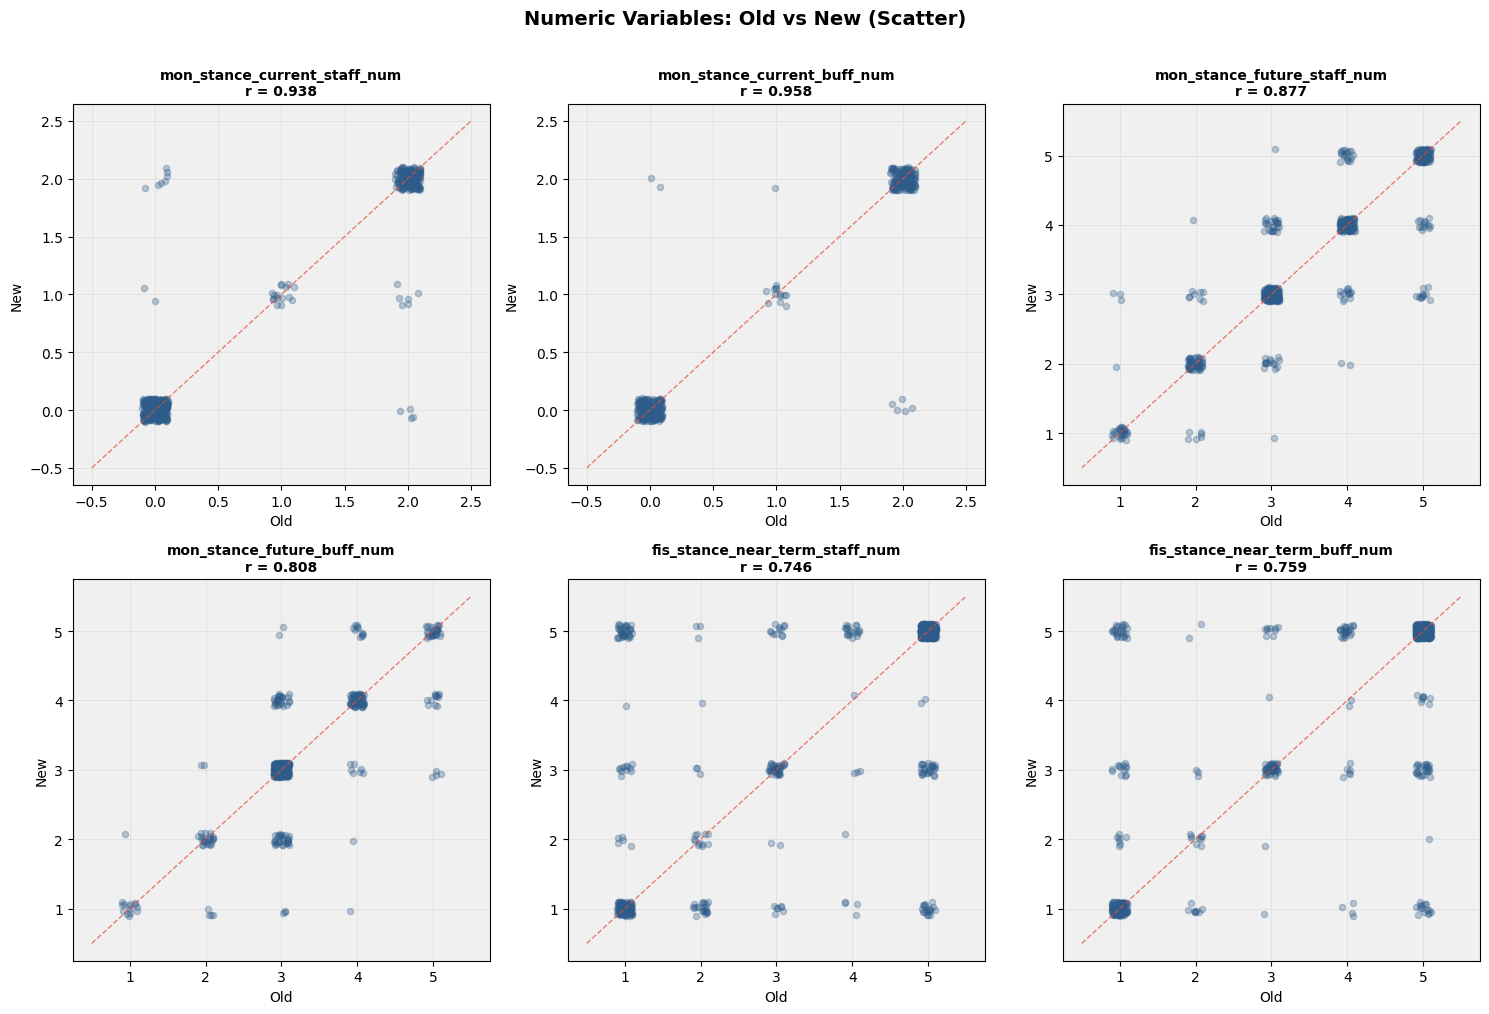

In [16]:
# ── Scatter plots: old vs new for key numeric variables ──────────────────────
scatter_cols = [
    "mon_stance_current_staff_num", "mon_stance_current_buff_num",
    "mon_stance_future_staff_num", "mon_stance_future_buff_num",
    "fis_stance_near_term_staff_num", "fis_stance_near_term_buff_num",
]
available_scatter = [c for c in scatter_cols
                     if f"{c}_old" in df_merged.columns and f"{c}_new" in df_merged.columns]

n_plots = len(available_scatter)
ncols = 3
nrows = (n_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes_flat = axes.flat if n_plots > 1 else [axes]

for ax, col in zip(axes_flat, available_scatter):
    col_old, col_new = f"{col}_old", f"{col}_new"
    old_v = pd.to_numeric(df_merged[col_old], errors="coerce")
    new_v = pd.to_numeric(df_merged[col_new], errors="coerce")
    valid = old_v.notna() & new_v.notna()

    # Add jitter for discrete values
    jitter = 0.1
    x = old_v[valid] + np.random.uniform(-jitter, jitter, valid.sum())
    y = new_v[valid] + np.random.uniform(-jitter, jitter, valid.sum())

    ax.scatter(x, y, alpha=0.3, s=20, color="#2E5C8A")

    # Diagonal reference line
    lims = [min(old_v[valid].min(), new_v[valid].min()) - 0.5,
            max(old_v[valid].max(), new_v[valid].max()) + 0.5]
    ax.plot(lims, lims, "--", color="#E74C3C", linewidth=1, alpha=0.7)

    corr = old_v[valid].corr(new_v[valid])
    ax.set_title(f"{col}\nr = {corr:.3f}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Old")
    ax.set_ylabel("New")
    dv.style_axes(ax, grid=True, grid_axis="both")

# Hide unused axes
for ax in list(axes_flat)[n_plots:]:
    ax.set_visible(False)

plt.suptitle("Numeric Variables: Old vs New (Scatter)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

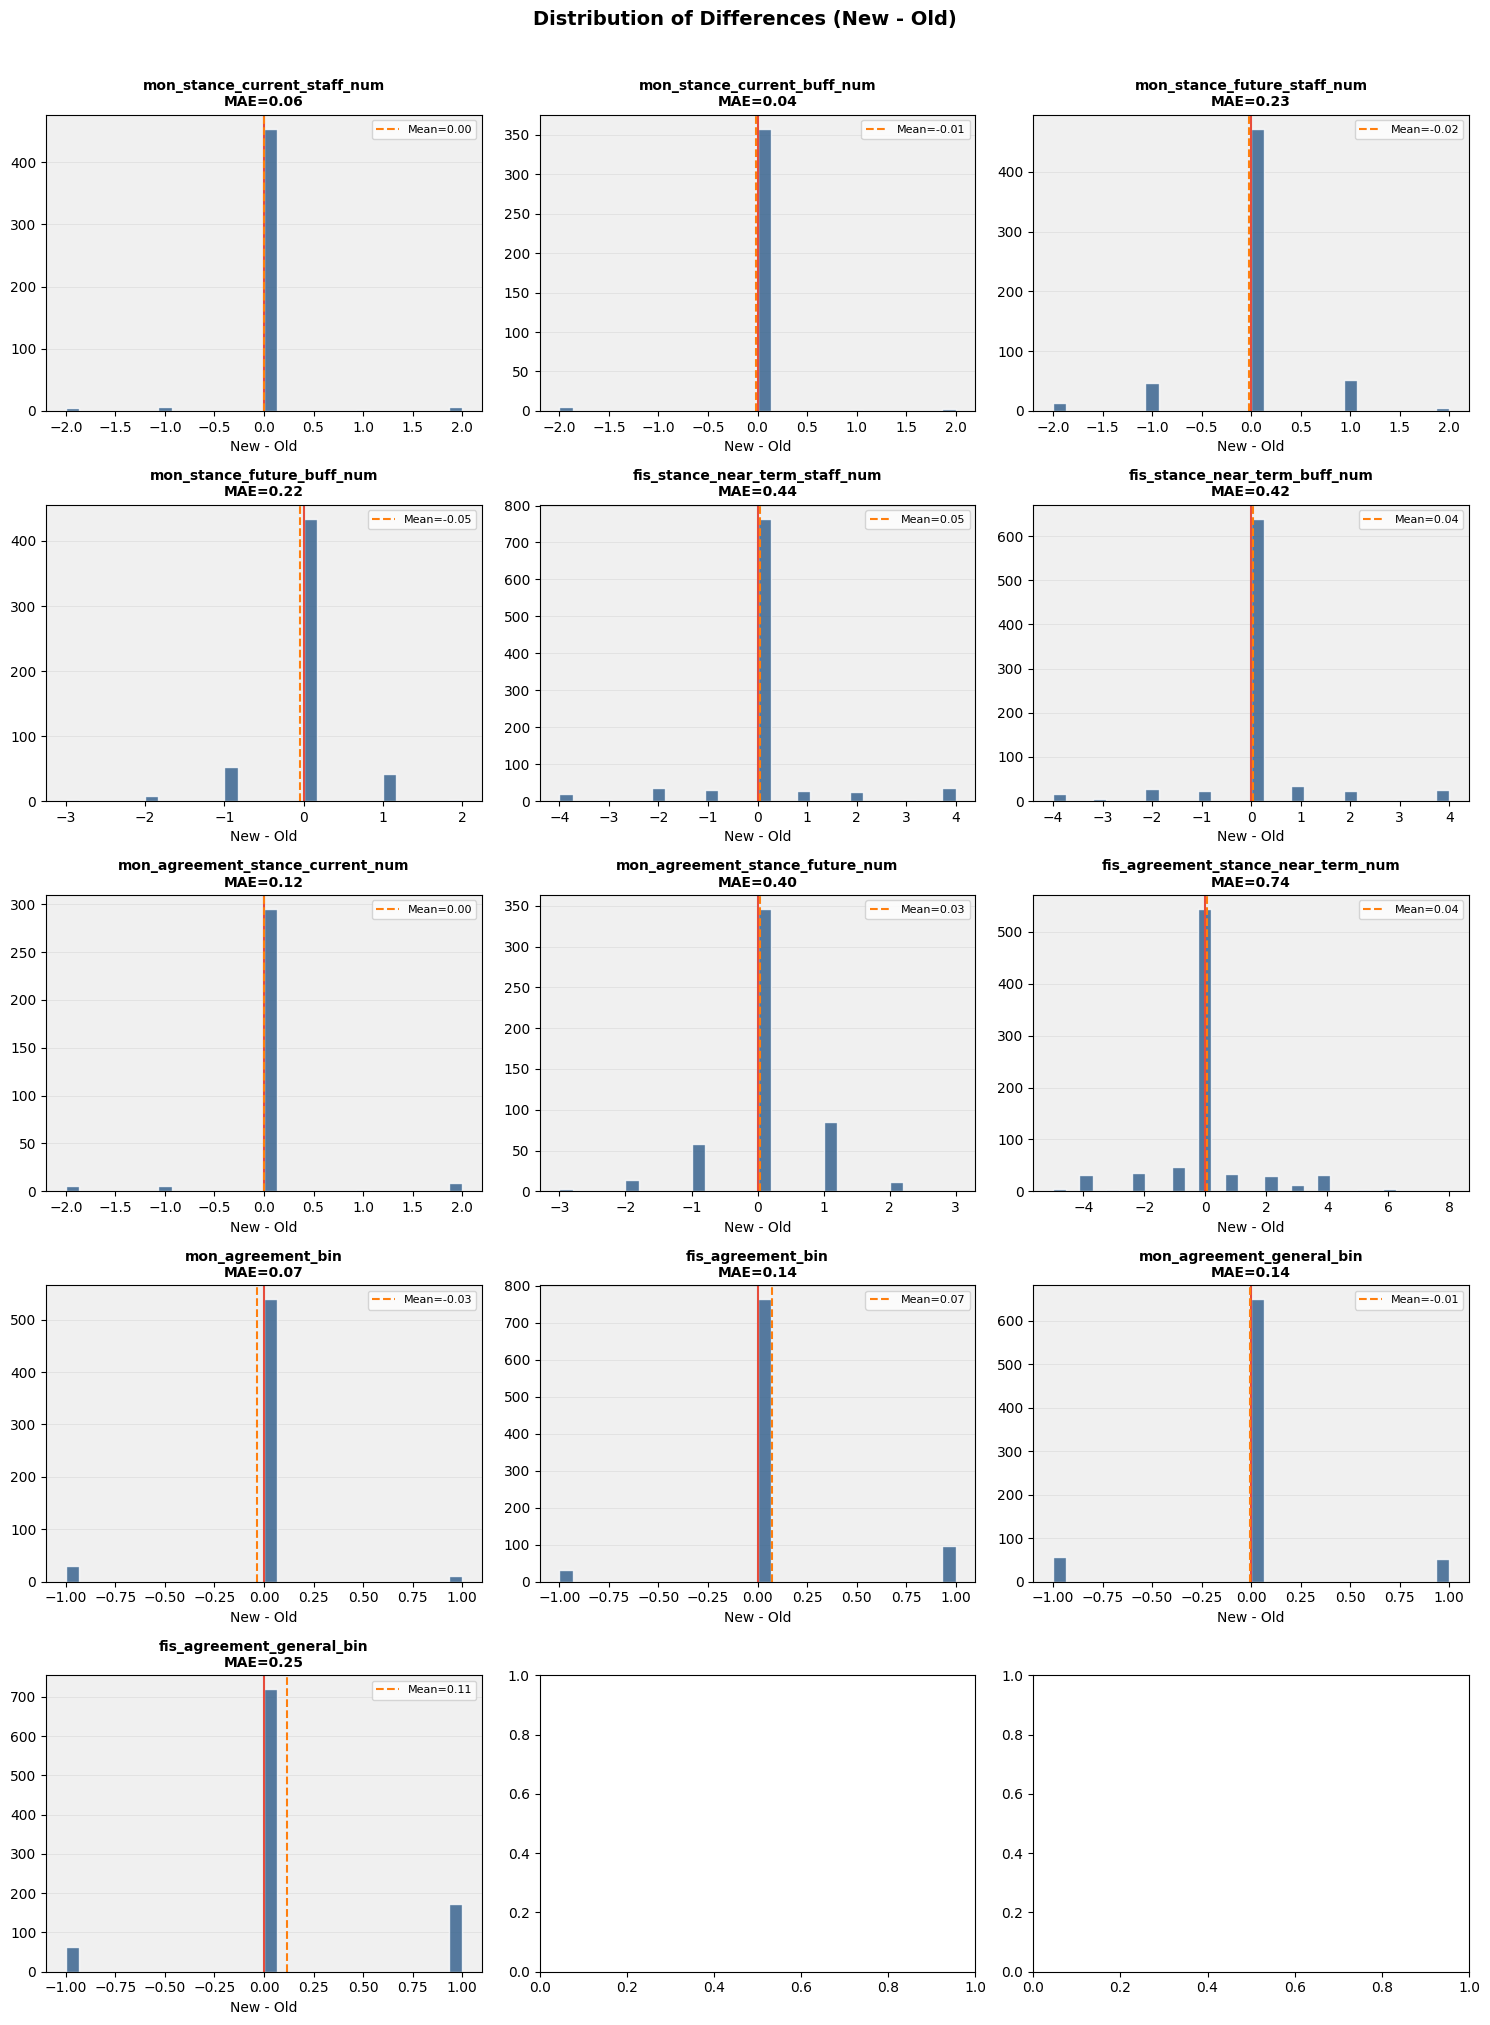

In [17]:
# ── Difference histograms ────────────────────────────────────────────────────
available_num = [c for c in NUMERIC_COLS
                 if f"{c}_old" in df_merged.columns and f"{c}_new" in df_merged.columns]

n_plots = len(available_num)
ncols = 3
nrows = (n_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat = axes.flat if n_plots > 1 else [axes]

for ax, col in zip(axes_flat, available_num):
    col_old, col_new = f"{col}_old", f"{col}_new"
    old_v = pd.to_numeric(df_merged[col_old], errors="coerce")
    new_v = pd.to_numeric(df_merged[col_new], errors="coerce")
    valid = old_v.notna() & new_v.notna()
    diff = new_v[valid] - old_v[valid]

    ax.hist(diff, bins=30, color="#2E5C8A", edgecolor="white", alpha=0.8)
    ax.axvline(x=0, color="#E74C3C", linewidth=1.5)
    ax.axvline(x=diff.mean(), color="#FF7F0E", linewidth=1.5, linestyle="--",
               label=f"Mean={diff.mean():.2f}")
    ax.set_title(f"{col}\nMAE={diff.abs().mean():.2f}", fontsize=10, fontweight="bold")
    ax.set_xlabel("New - Old")
    ax.legend(fontsize=8)
    dv.style_axes(ax)

for ax in list(axes_flat)[n_plots:]:
    ax.set_visible(False)

plt.suptitle("Distribution of Differences (New - Old)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3827265/2208150570.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="income_group", y="diff", order=INCOME_GROUP_ORDER,
/tmp/ipykernel_3827265/2208150570.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="income_group", y="diff", order=INCOME_GROUP_ORDER,
/tmp/ipykernel_3827265/2208150570.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="income_group", y="diff", order=INCOME_GROUP_ORDER,
/tmp/ipykernel_3827265/2208150570.py:30: FutureWarning: 

Passing `palette` without assigning 

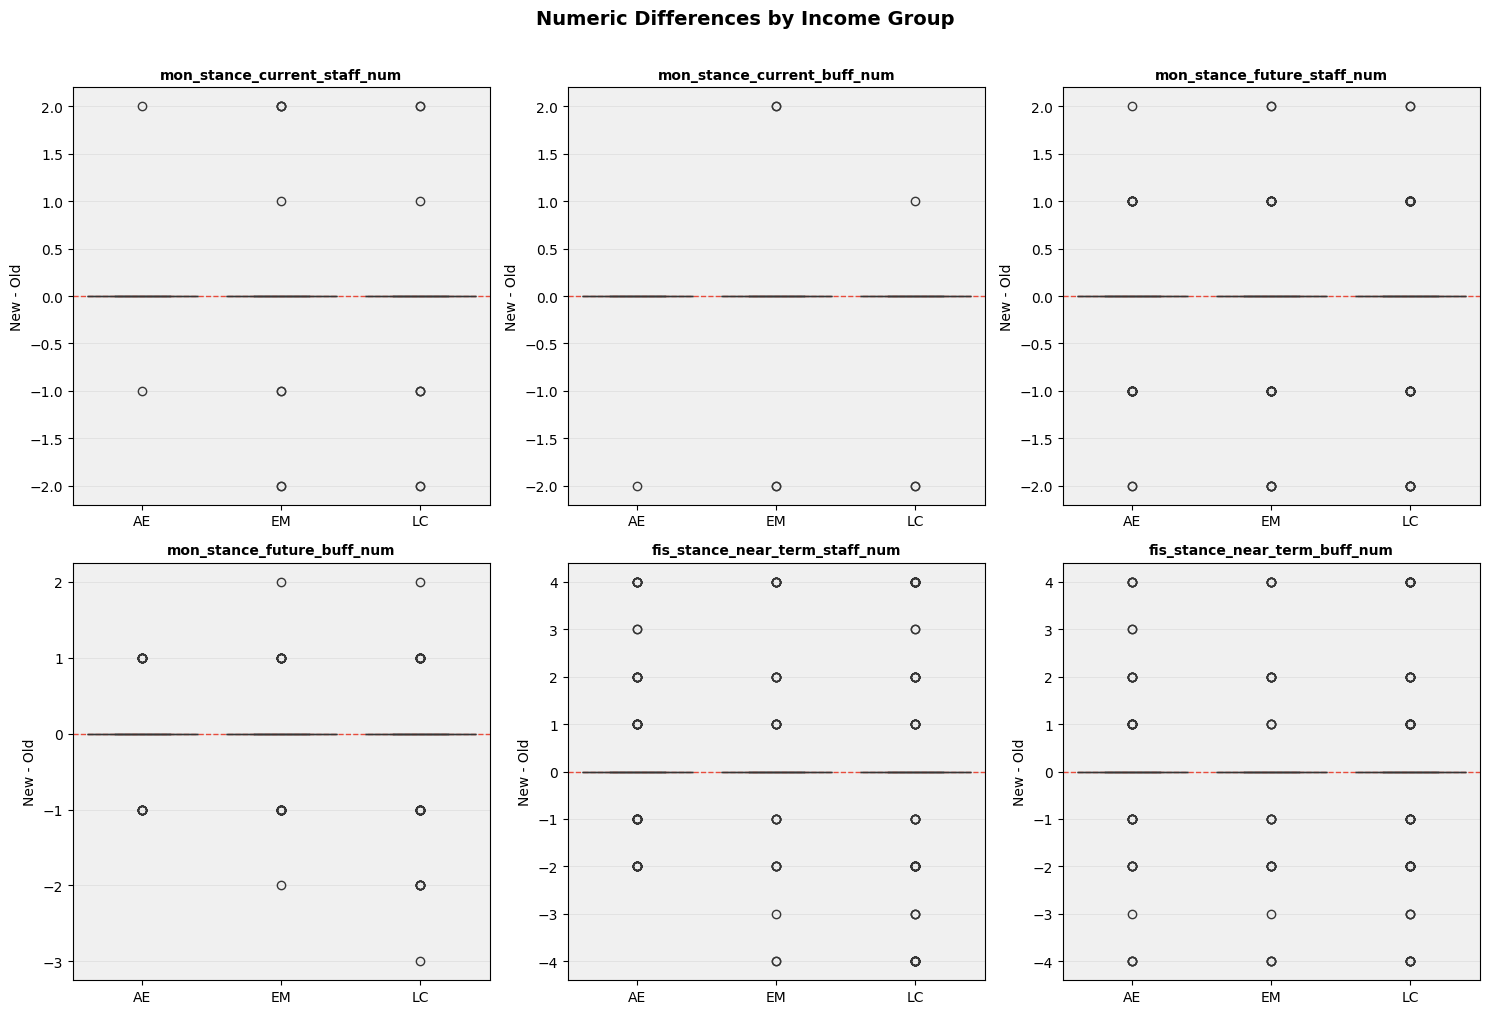

In [18]:
# ── Box plots of numeric differences by income group ─────────────────────────
diff_rows = []
for col in available_num:
    col_old, col_new = f"{col}_old", f"{col}_new"
    old_v = pd.to_numeric(df_merged[col_old], errors="coerce")
    new_v = pd.to_numeric(df_merged[col_new], errors="coerce")
    valid = old_v.notna() & new_v.notna()
    diff = new_v[valid] - old_v[valid]
    for idx in diff.index:
        ig = df_merged.loc[idx, "income_group"]
        diff_rows.append({"variable": col, "income_group": ig, "diff": diff[idx]})

df_diffs = pd.DataFrame(diff_rows)

# Pick top 6 most interesting numeric cols
top_num_cols = available_num[:6]
n_plots = len(top_num_cols)
ncols = 3
nrows = (n_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes_flat = axes.flat if n_plots > 1 else [axes]

for ax, col in zip(axes_flat, top_num_cols):
    sub = df_diffs[df_diffs["variable"] == col]
    sub = sub[sub["income_group"].isin(INCOME_GROUP_ORDER)]
    if sub.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        continue
    sns.boxplot(data=sub, x="income_group", y="diff", order=INCOME_GROUP_ORDER,
                palette=INCOME_COLORS, ax=ax)
    ax.axhline(y=0, color="#E74C3C", linewidth=1, linestyle="--")
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("New - Old")
    dv.style_axes(ax)

for ax in list(axes_flat)[n_plots:]:
    ax.set_visible(False)

plt.suptitle("Numeric Differences by Income Group", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

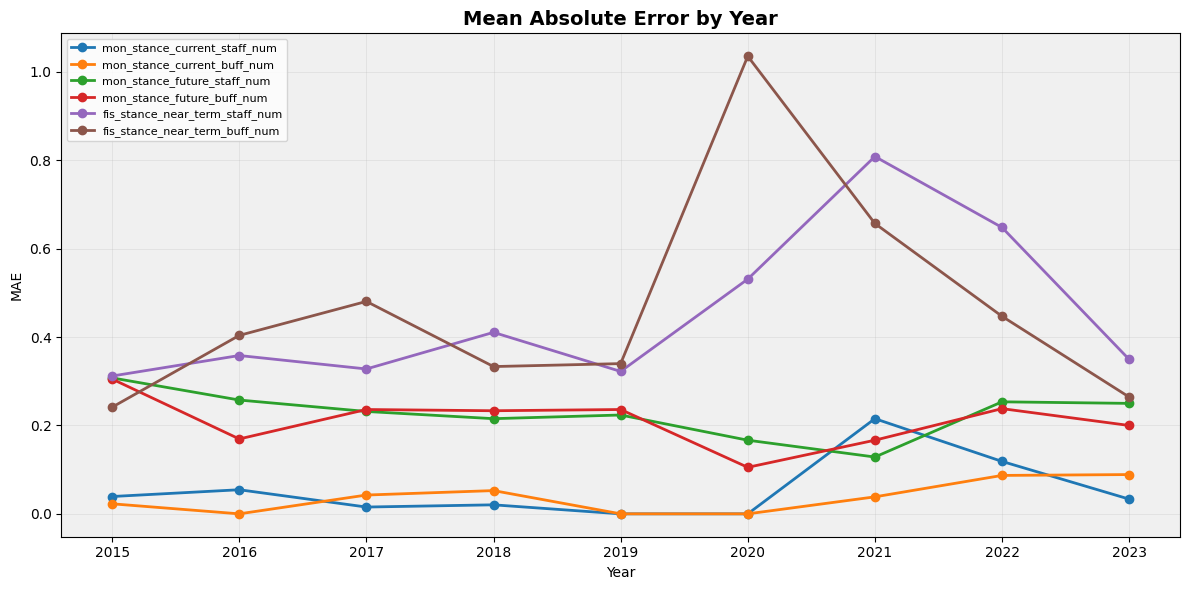

In [19]:
# ── MAE by year ──────────────────────────────────────────────────────────────
yr_mae_rows = []
for col in available_num:
    col_old, col_new = f"{col}_old", f"{col}_new"
    for yr in sorted(df_merged["year"].dropna().unique()):
        sub = df_merged[df_merged["year"] == yr]
        old_v = pd.to_numeric(sub[col_old], errors="coerce")
        new_v = pd.to_numeric(sub[col_new], errors="coerce")
        valid = old_v.notna() & new_v.notna()
        n = valid.sum()
        mae = (new_v[valid] - old_v[valid]).abs().mean() if n > 0 else np.nan
        yr_mae_rows.append({"variable": col, "year": int(yr), "mae": mae})

df_yr_mae = pd.DataFrame(yr_mae_rows)

fig, ax = plt.subplots(figsize=(12, 6))
for col in available_num[:6]:  # limit to 6 for readability
    sub = df_yr_mae[df_yr_mae["variable"] == col]
    ax.plot(sub["year"], sub["mae"], marker="o", linewidth=2, label=col)

ax.set_xlabel("Year")
ax.set_ylabel("MAE")
ax.set_title("Mean Absolute Error by Year", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=8)
dv.style_axes(ax, grid=True, grid_axis="both")
plt.tight_layout()
plt.show()

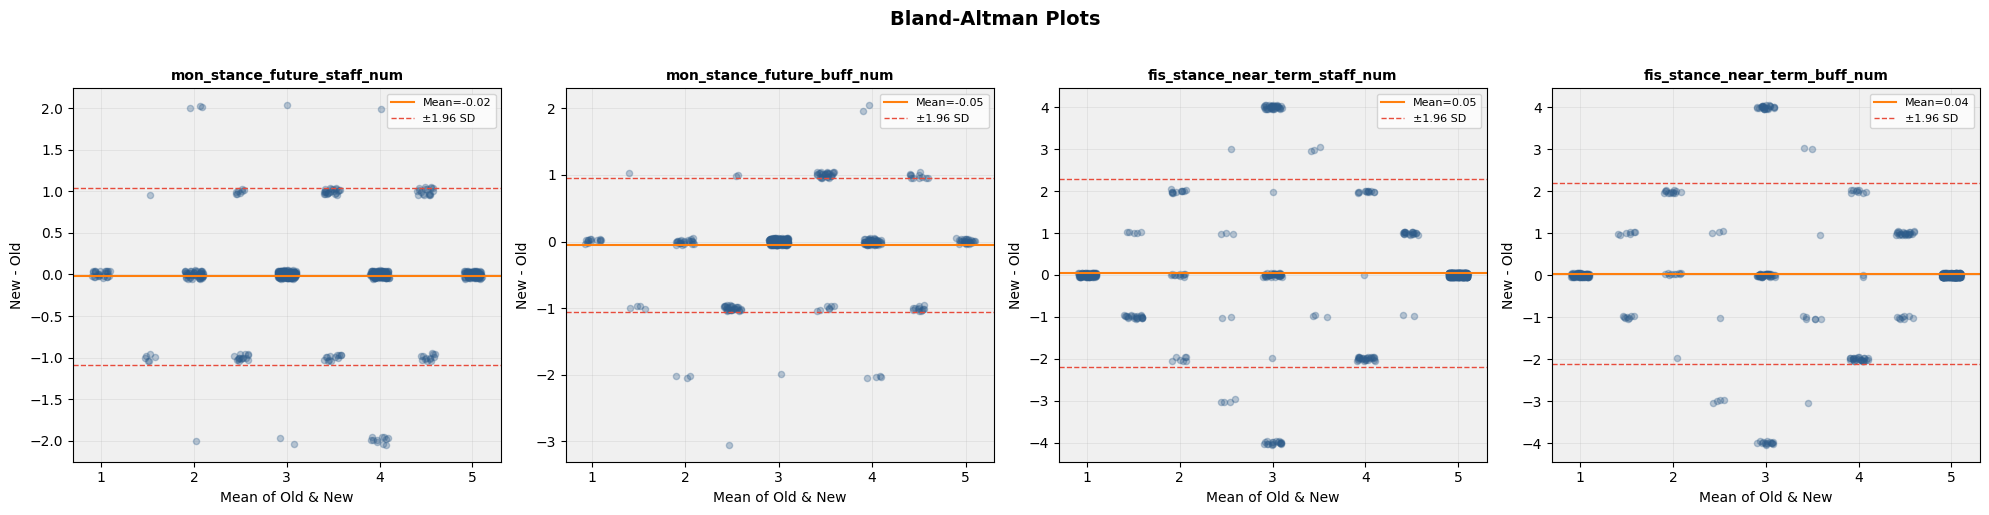

In [20]:
# ── Bland-Altman plots for 1-5 scale variables ───────────────────────────────
ba_cols = [c for c in ["mon_stance_future_staff_num", "mon_stance_future_buff_num",
                        "fis_stance_near_term_staff_num", "fis_stance_near_term_buff_num"]
           if f"{c}_old" in df_merged.columns and f"{c}_new" in df_merged.columns]

if ba_cols:
    n_plots = len(ba_cols)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]

    for ax, col in zip(axes, ba_cols):
        col_old, col_new = f"{col}_old", f"{col}_new"
        old_v = pd.to_numeric(df_merged[col_old], errors="coerce")
        new_v = pd.to_numeric(df_merged[col_new], errors="coerce")
        valid = old_v.notna() & new_v.notna()

        mean_val = (old_v[valid] + new_v[valid]) / 2
        diff_val = new_v[valid] - old_v[valid]

        ax.scatter(mean_val + np.random.uniform(-0.1, 0.1, valid.sum()),
                   diff_val + np.random.uniform(-0.05, 0.05, valid.sum()),
                   alpha=0.3, s=20, color="#2E5C8A")

        mean_d = diff_val.mean()
        std_d = diff_val.std()
        ax.axhline(y=mean_d, color="#FF7F0E", linewidth=1.5, label=f"Mean={mean_d:.2f}")
        ax.axhline(y=mean_d + 1.96 * std_d, color="#E74C3C", linewidth=1, linestyle="--")
        ax.axhline(y=mean_d - 1.96 * std_d, color="#E74C3C", linewidth=1, linestyle="--",
                   label=f"±1.96 SD")

        ax.set_title(col, fontsize=10, fontweight="bold")
        ax.set_xlabel("Mean of Old & New")
        ax.set_ylabel("New - Old")
        ax.legend(fontsize=8)
        dv.style_axes(ax, grid=True, grid_axis="both")

    plt.suptitle("Bland-Altman Plots", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

## Section 4: Country-Level Deviation Analysis

In [21]:
# ── Per-country match rates ──────────────────────────────────────────────────
country_key_cols = [
    "mon_stance_current_staff", "mon_stance_future_staff",
    "fis_stance_near_term_staff",
    "mon_agreement_stance_future", "fis_agreement_stance_near_term",
]

country_rows = []
for cc, grp in df_merged.groupby("Primary Country Code"):
    row = {
        "country_code": cc,
        "country_name": grp["country_name"].iloc[0] if "country_name" in grp.columns else cc,
        "income_group": grp["income_group"].iloc[0] if "income_group" in grp.columns else "Unknown",
        "n_obs": len(grp),
    }
    match_rates = []
    for col in country_key_cols:
        col_old, col_new = f"{col}_old", f"{col}_new"
        if col_old not in grp.columns or col_new not in grp.columns:
            row[f"{col}_match%"] = np.nan
            continue
        old_v = grp[col_old].astype(str).str.strip().str.lower().replace("nan", np.nan)
        new_v = grp[col_new].astype(str).str.strip().str.lower().replace("nan", np.nan)
        valid = old_v.notna() & new_v.notna()
        n = valid.sum()
        rate = (old_v[valid] == new_v[valid]).mean() * 100 if n > 0 else np.nan
        row[f"{col}_match%"] = rate
        if not np.isnan(rate):
            match_rates.append(rate)

    row["overall_match%"] = np.mean(match_rates) if match_rates else np.nan
    country_rows.append(row)

df_country = pd.DataFrame(country_rows).sort_values("overall_match%")

print(f"Country-level match rates ({len(df_country)} countries):")
print(f"  Mean overall match: {df_country['overall_match%'].mean():.1f}%")
print(f"  Median overall match: {df_country['overall_match%'].median():.1f}%")
print(f"  Min overall match: {df_country['overall_match%'].min():.1f}%")
print(f"  Max overall match: {df_country['overall_match%'].max():.1f}%")

display(df_country.head(20).style.background_gradient(
    subset=[c for c in df_country.columns if "match%" in c],
    cmap="RdYlGn", vmin=0, vmax=100,
).format({c: "{:.1f}" for c in df_country.columns if "match%" in c}))

/tmp/ipykernel_3827265/3356143325.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  old_v = grp[col_old].astype(str).str.strip().str.lower().replace("nan", np.nan)
/tmp/ipykernel_3827265/3356143325.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_v = grp[col_new].astype(str).str.strip().str.lower().replace("nan", np.nan)
/tmp/ipykernel_3827265/3356143325.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer

Country-level match rates (191 countries):
  Mean overall match: 76.3%
  Median overall match: 79.4%
  Min overall match: 0.0%
  Max overall match: 100.0%


/tmp/ipykernel_3827265/3356143325.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  old_v = grp[col_old].astype(str).str.strip().str.lower().replace("nan", np.nan)
/tmp/ipykernel_3827265/3356143325.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_v = grp[col_new].astype(str).str.strip().str.lower().replace("nan", np.nan)
/tmp/ipykernel_3827265/3356143325.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer

,country_code,country_name,income_group,n_obs,mon_stance_current_staff_match%,mon_stance_future_staff_match%,fis_stance_near_term_staff_match%,mon_agreement_stance_future_match%,fis_agreement_stance_near_term_match%,overall_match%
31,CEE,Slovenia,LC,1,nan,nan,0.0,nan,0.0,0.0
108,MAC,Macao SAR,LC,3,0.0,0.0,66.7,100.0,0.0,33.3
74,HKG,Hong Kong SAR,AE,7,33.3,16.7,71.4,16.7,57.1,39.0
130,NLD,Netherlands,AE,6,33.3,0.0,83.3,66.7,16.7,40.0
46,DEU,Germany,AE,9,12.5,0.0,55.6,100.0,55.6,44.7
58,FIN,Finland,AE,7,33.3,0.0,71.4,66.7,57.1,45.7
81,IRL,Ireland,AE,8,0.0,0.0,75.0,100.0,62.5,47.5
55,EST,Estonia,AE,7,25.0,0.0,42.9,100.0,71.4,47.9
69,GNQ,Equatorial Guinea,LC,3,0.0,nan,100.0,0.0,100.0,50.0
94,KIR,Kiribati,LC,5,nan,nan,60.0,nan,40.0,50.0


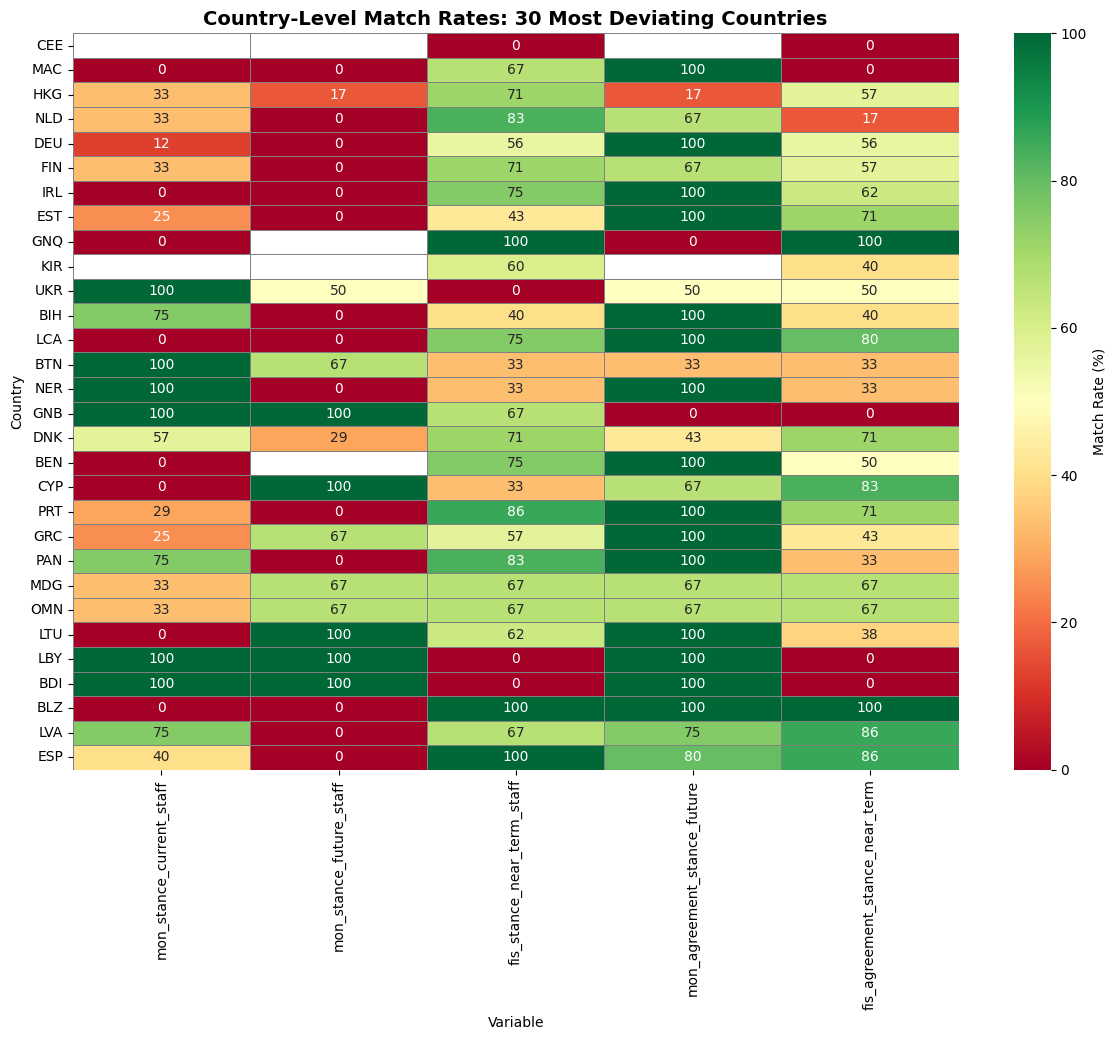

In [22]:
# ── Country heatmap: bottom 30 countries by match rate ───────────────────────
match_cols = [c for c in df_country.columns if "match%" in c and c != "overall_match%"]
bottom_30 = df_country.head(30)

heatmap_data = bottom_30.set_index("country_code")[match_cols]
heatmap_data.columns = [c.replace("_match%", "") for c in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(12, max(8, len(bottom_30) * 0.35)))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="RdYlGn",
            vmin=0, vmax=100, ax=ax, linewidths=0.5, linecolor="grey",
            cbar_kws={"label": "Match Rate (%)"})
ax.set_title("Country-Level Match Rates: 30 Most Deviating Countries",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Variable")
ax.set_ylabel("Country")
plt.tight_layout()
plt.show()

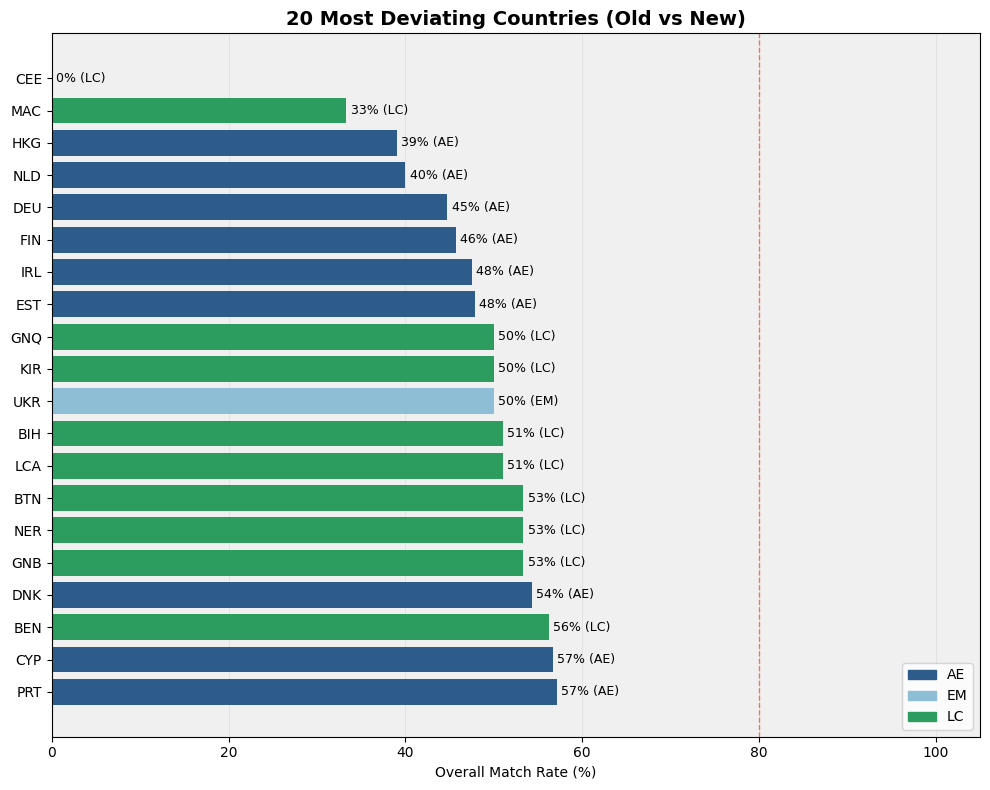

In [23]:
# ── Top 20 most-deviating countries (bar chart) ──────────────────────────────
top_20_dev = df_country.head(20).copy()

fig, ax = plt.subplots(figsize=(10, 8))
colors = [INCOME_COLORS.get(ig, "#999") for ig in top_20_dev["income_group"]]
bars = ax.barh(top_20_dev["country_code"], top_20_dev["overall_match%"], color=colors)

ax.set_xlabel("Overall Match Rate (%)")
ax.set_title("20 Most Deviating Countries (Old vs New)", fontsize=14, fontweight="bold")
ax.set_xlim(0, 105)
ax.axvline(x=80, color="#E74C3C", linestyle="--", linewidth=1, alpha=0.7)
ax.invert_yaxis()

# Annotate with income group
for bar, (_, row) in zip(bars, top_20_dev.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{row['overall_match%']:.0f}% ({row['income_group']})",
            va="center", fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=g) for g, c in INCOME_COLORS.items()]
ax.legend(handles=legend_handles, loc="lower right")

dv.style_axes(ax, grid=True, grid_axis="x")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3827265/1865941522.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x="income_group", y="overall_match%",


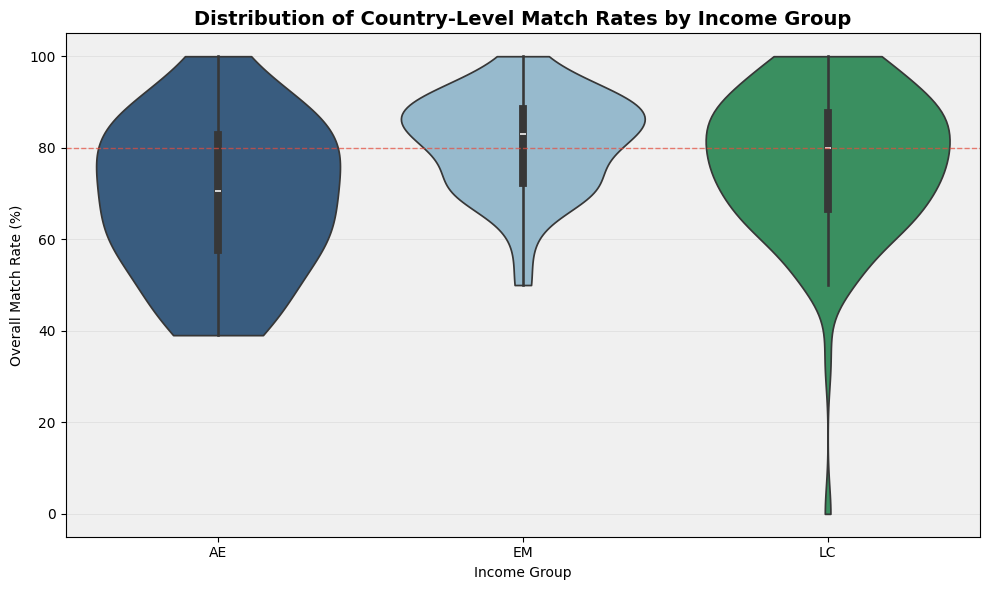

In [24]:
# ── Distribution of per-country match rates by income group ──────────────────
fig, ax = plt.subplots(figsize=(10, 6))

plot_data = df_country[df_country["income_group"].isin(INCOME_GROUP_ORDER)].copy()
sns.violinplot(data=plot_data, x="income_group", y="overall_match%",
               order=INCOME_GROUP_ORDER, palette=INCOME_COLORS, ax=ax,
               inner="box", cut=0)

ax.set_xlabel("Income Group")
ax.set_ylabel("Overall Match Rate (%)")
ax.set_title("Distribution of Country-Level Match Rates by Income Group",
             fontsize=14, fontweight="bold")
ax.set_ylim(-5, 105)
ax.axhline(y=80, color="#E74C3C", linestyle="--", linewidth=1, alpha=0.7)
dv.style_axes(ax, grid=True, grid_axis="y")
plt.tight_layout()
plt.show()

In [25]:
# ── Per-country MAE table for numeric variables ──────────────────────────────
country_mae_rows = []
num_key_cols = ["mon_stance_future_staff_num", "fis_stance_near_term_staff_num",
                "mon_agreement_stance_future_num", "fis_agreement_stance_near_term_num"]
num_key_available = [c for c in num_key_cols
                     if f"{c}_old" in df_merged.columns and f"{c}_new" in df_merged.columns]

for cc, grp in df_merged.groupby("Primary Country Code"):
    row = {
        "country_code": cc,
        "country_name": grp["country_name"].iloc[0] if "country_name" in grp.columns else cc,
        "income_group": grp["income_group"].iloc[0] if "income_group" in grp.columns else "Unknown",
    }
    maes = []
    for col in num_key_available:
        old_v = pd.to_numeric(grp[f"{col}_old"], errors="coerce")
        new_v = pd.to_numeric(grp[f"{col}_new"], errors="coerce")
        valid = old_v.notna() & new_v.notna()
        mae = (new_v[valid] - old_v[valid]).abs().mean() if valid.sum() > 0 else np.nan
        row[f"MAE_{col}"] = mae
        if not np.isnan(mae):
            maes.append(mae)
    row["avg_MAE"] = np.mean(maes) if maes else np.nan
    country_mae_rows.append(row)

df_country_mae = pd.DataFrame(country_mae_rows).sort_values("avg_MAE", ascending=False)

print("Top 20 countries by average numeric MAE:")
display(df_country_mae.head(20).style.background_gradient(
    subset=[c for c in df_country_mae.columns if "MAE" in c],
    cmap="YlOrRd",
).format({c: "{:.2f}" for c in df_country_mae.columns if "MAE" in c}))

Top 20 countries by average numeric MAE:


,country_code,country_name,income_group,MAE_mon_stance_future_staff_num,MAE_fis_stance_near_term_staff_num,MAE_mon_agreement_stance_future_num,MAE_fis_agreement_stance_near_term_num,avg_MAE
94,KIR,Kiribati,LC,nan,1.20,nan,4.00,2.60
20,BIH,Bosnia and Herzegovina,LC,nan,1.40,nan,3.00,2.20
31,CEE,Slovenia,LC,nan,2.00,nan,2.00,2.00
179,UKR,Ukraine,EM,0.50,2.50,0.50,4.50,2.00
127,NER,Niger,LC,1.00,2.67,1.00,2.67,1.83
13,BDI,Burundi,LC,0.00,4.00,1.00,nan,1.67
53,EGY,Egypt,EM,0.50,2.00,0.50,3.50,1.62
74,HKG,Hong Kong SAR,AE,2.00,0.86,2.00,1.25,1.53
184,VCT,St. Vincent and the Grenadines,LC,nan,0.33,nan,2.50,1.42
73,GUY,Guyana,LC,0.17,1.83,0.17,3.20,1.34


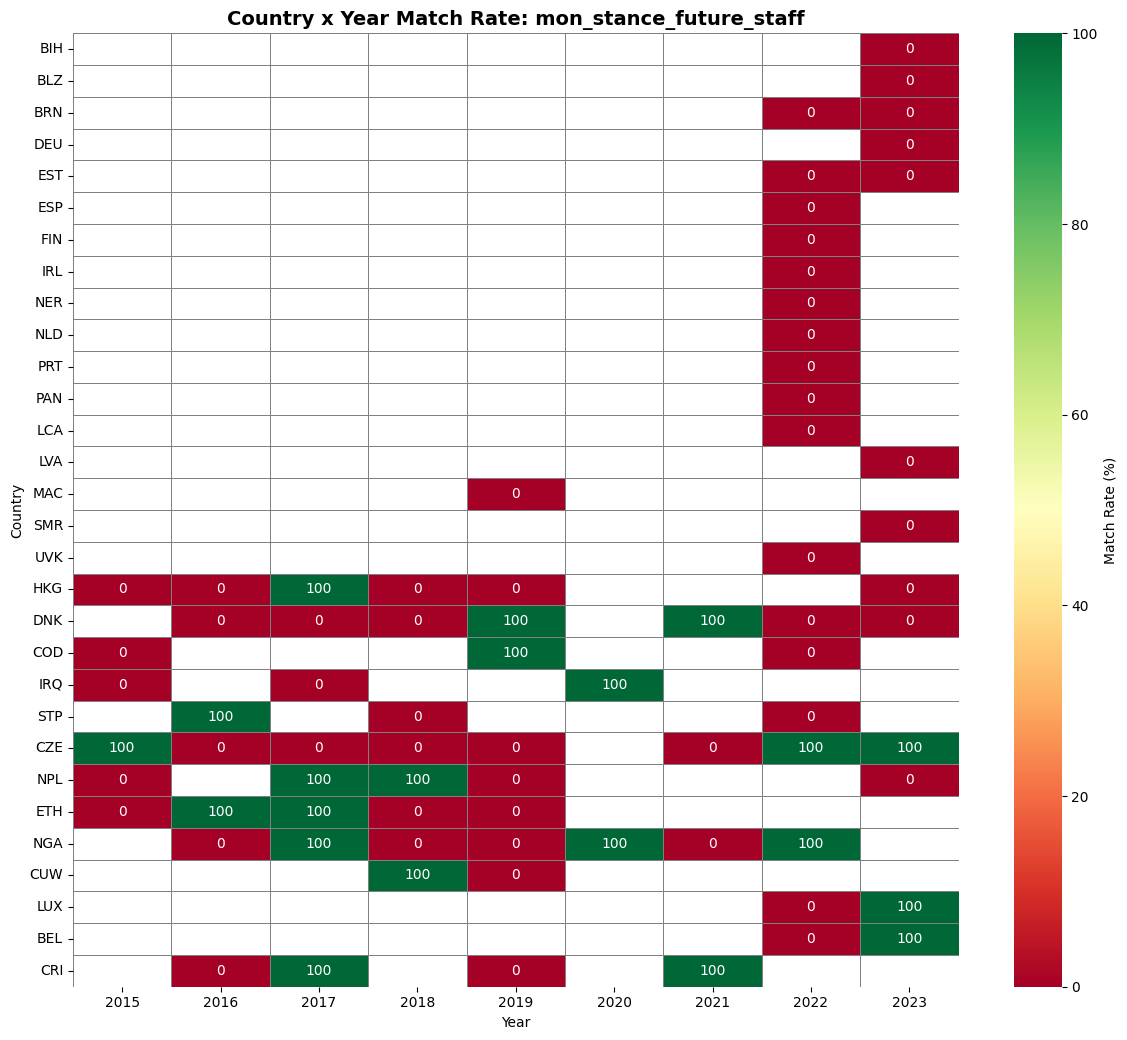

In [26]:
# ── Country x Year heatmap for mon_stance_future_staff ───────────────────────
focus_col = "mon_stance_future_staff"
col_old, col_new = f"{focus_col}_old", f"{focus_col}_new"

if col_old in df_merged.columns and col_new in df_merged.columns:
    # Compute match/mismatch per observation
    df_merged["_focus_match"] = (
        df_merged[col_old].astype(str).str.strip().str.lower().replace("nan", np.nan)
        == df_merged[col_new].astype(str).str.strip().str.lower().replace("nan", np.nan)
    ).astype(float)
    # NaN where either is missing
    both_valid = (
        df_merged[col_old].astype(str).str.strip().str.lower().replace("nan", np.nan).notna()
        & df_merged[col_new].astype(str).str.strip().str.lower().replace("nan", np.nan).notna()
    )
    df_merged.loc[~both_valid, "_focus_match"] = np.nan

    # Get top 30 most deviating countries
    country_match_rate = (df_merged.groupby("Primary Country Code")["_focus_match"]
                          .mean().sort_values())
    top30_codes = country_match_rate.head(30).index.tolist()

    sub = df_merged[df_merged["Primary Country Code"].isin(top30_codes)].copy()
    pivot = sub.pivot_table(
        index="Primary Country Code", columns="year",
        values="_focus_match", aggfunc="mean",
    )
    # Reorder rows by overall match rate
    pivot = pivot.loc[top30_codes]

    fig, ax = plt.subplots(figsize=(12, max(8, len(top30_codes) * 0.35)))
    sns.heatmap(pivot * 100, annot=True, fmt=".0f", cmap="RdYlGn",
                vmin=0, vmax=100, ax=ax, linewidths=0.5, linecolor="grey",
                cbar_kws={"label": "Match Rate (%)"})
    ax.set_title(f"Country x Year Match Rate: {focus_col}",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Country")
    plt.tight_layout()
    plt.show()

    df_merged.drop(columns=["_focus_match"], inplace=True)

In [27]:
# ── Detailed mismatch table: top deviating country-year pairs ────────────────
detail_cols = ["mon_stance_future_staff", "fis_stance_near_term_staff",
               "mon_agreement_stance_future", "fis_agreement_stance_near_term"]

mismatch_rows = []
for idx, row in df_merged.iterrows():
    for col in detail_cols:
        col_old, col_new = f"{col}_old", f"{col}_new"
        if col_old not in df_merged.columns or col_new not in df_merged.columns:
            continue
        old_v = str(row[col_old]).strip().lower() if pd.notna(row[col_old]) else None
        new_v = str(row[col_new]).strip().lower() if pd.notna(row[col_new]) else None
        if old_v and new_v and old_v != "nan" and new_v != "nan" and old_v != new_v:
            mismatch_rows.append({
                "country": row.get("Primary Country Code", "?"),
                "year": row.get("year", "?"),
                "variable": col,
                "old_value": old_v,
                "new_value": new_v,
            })

df_mismatches = pd.DataFrame(mismatch_rows)
print(f"Total mismatched cells: {len(df_mismatches)}")

# Show top 30 rows
if not df_mismatches.empty:
    print("\nSample of mismatched observations:")
    display(df_mismatches.head(30))

Total mismatched cells: 715

Sample of mismatched observations:


,country,year,variable,old_value,new_value
0,AFG,2015,fis_agreement_stance_near_term,irrelevant,disagreement exists
1,AFG,2017,fis_stance_near_term_staff,tightening,no change / unclear
2,AFG,2019,fis_agreement_stance_near_term,irrelevant,disagreement exists
3,ALB,2016,mon_agreement_stance_future,disagreement exists,mostly agree
4,ALB,2017,mon_stance_future_staff,no change / unclear,tightening bias
5,ALB,2018,fis_agreement_stance_near_term,irrelevant,mostly agree
6,DZA,2016,mon_stance_future_staff,no change / unclear,tightening bias
7,DZA,2021,mon_stance_future_staff,tightening,no change / unclear
8,DZA,2021,mon_agreement_stance_future,disagreement exists,mostly agree
9,DZA,2022,mon_agreement_stance_future,disagreement exists,mostly agree


## Section 5: Disagreement Areas Text Comparison

In [28]:
# ── Parse disagreement areas and compute Jaccard similarity ──────────────────
def safe_parse_list(text):
    """Parse a string representation of a list. Return empty set on failure."""
    if pd.isna(text) or str(text).strip() in ("", "nan", "[]"):
        return set()
    try:
        parsed = ast.literal_eval(str(text))
        if isinstance(parsed, (list, set)):
            return {str(x).strip().lower() for x in parsed if str(x).strip()}
    except (ValueError, SyntaxError):
        pass
    # Fallback: try splitting by comma
    return {x.strip().lower() for x in str(text).strip("[]").split(",") if x.strip()}


def jaccard_similarity(set_a, set_b):
    if not set_a and not set_b:
        return 1.0  # both empty -> agreement
    union = set_a | set_b
    if not union:
        return 1.0
    return len(set_a & set_b) / len(union)


for area_col in ["mon_disagreement_areas", "fis_disagreement_areas"]:
    col_old, col_new = f"{area_col}_old", f"{area_col}_new"
    if col_old not in df_merged.columns or col_new not in df_merged.columns:
        print(f"{area_col}: not available in both datasets")
        continue

    old_sets = df_merged[col_old].apply(safe_parse_list)
    new_sets = df_merged[col_new].apply(safe_parse_list)

    # Only compare where at least one has content
    has_content = old_sets.apply(bool) | new_sets.apply(bool)

    jaccard_scores = pd.Series(
        [jaccard_similarity(o, n) for o, n in zip(old_sets[has_content], new_sets[has_content])],
        index=has_content[has_content].index,
    )
    exact_match = (old_sets[has_content].values == new_sets[has_content].values)

    print(f"\n{area_col}:")
    print(f"  Pairs with content: {has_content.sum()}")
    print(f"  Mean Jaccard similarity: {jaccard_scores.mean():.3f}")
    print(f"  Median Jaccard similarity: {jaccard_scores.median():.3f}")
    print(f"  Exact set match rate: {exact_match.mean() * 100:.1f}%")


mon_disagreement_areas:
  Pairs with content: 111
  Mean Jaccard similarity: 0.284
  Median Jaccard similarity: 0.000
  Exact set match rate: 27.0%

fis_disagreement_areas:
  Pairs with content: 551
  Mean Jaccard similarity: 0.159
  Median Jaccard similarity: 0.000
  Exact set match rate: 12.5%


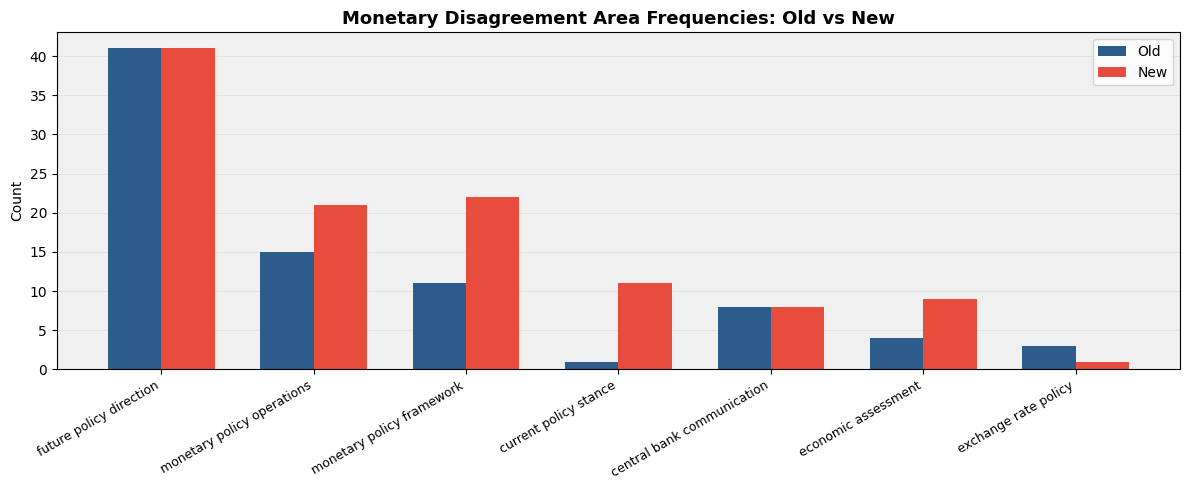

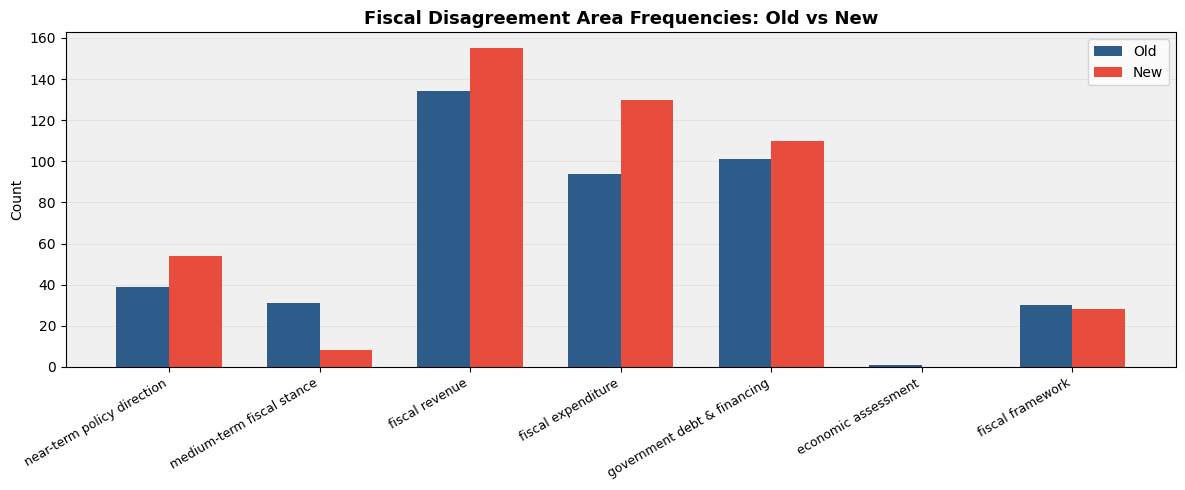

In [29]:
# ── Category frequency comparison ────────────────────────────────────────────
MONETARY_DISAGREE_CATEGORIES = {
    "future policy direction":    ["future policy direction", "forward guidance", "policy path"],
    "monetary policy operations": ["monetary policy operations", "policy operations"],
    "monetary policy framework":  ["monetary policy framework", "policy framework"],
    "current policy stance":      ["current policy stance", "policy stance"],
    "central bank communication": ["monetary policy communication",
                                   "central bank communication", "communication"],
    "economic assessment":        ["economic assessment"],
    "exchange rate policy":       ["exchange rate policy", "exchange rate regime",
                                   "exchange rate flexibility"],
}

FISCAL_DISAGREE_CATEGORIES = {
    "near-term policy direction": ["near-term", "short term", "frontload"],
    "medium-term fiscal stance":  ["medium-term", "medium term", "fiscal stance"],
    "fiscal revenue":             ["revenue", "tax"],
    "fiscal expenditure":         ["expenditure", "spending"],
    "government debt & financing": ["debt", "borrowing", "financing"],
    "economic assessment":        ["economic outlook", "growth", "inflation"],
    "fiscal framework":           ["fiscal rule", "framework"],
}


def count_categories(series, categories):
    """Count how often each category appears across a series of text."""
    counts = {cat: 0 for cat in categories}
    for text in series.dropna():
        text_lower = str(text).lower()
        for cat, keywords in categories.items():
            for kw in keywords:
                if kw.lower() in text_lower:
                    counts[cat] += 1
                    break
    return counts


for area_col, categories, title_prefix in [
    ("mon_disagreement_areas", MONETARY_DISAGREE_CATEGORIES, "Monetary"),
    ("fis_disagreement_areas", FISCAL_DISAGREE_CATEGORIES, "Fiscal"),
]:
    col_old, col_new = f"{area_col}_old", f"{area_col}_new"
    if col_old not in df_merged.columns or col_new not in df_merged.columns:
        continue

    old_counts = count_categories(df_merged[col_old], categories)
    new_counts = count_categories(df_merged[col_new], categories)

    cats = list(categories.keys())
    x = np.arange(len(cats))
    w = 0.35

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - w / 2, [old_counts[c] for c in cats], w, label="Old", color="#2E5C8A")
    ax.bar(x + w / 2, [new_counts[c] for c in cats], w, label="New", color="#E74C3C")
    ax.set_xticks(x)
    ax.set_xticklabels(cats, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Count")
    ax.set_title(f"{title_prefix} Disagreement Area Frequencies: Old vs New",
                 fontsize=13, fontweight="bold")
    ax.legend()
    dv.style_axes(ax)
    plt.tight_layout()
    plt.show()

## Section 6: Summary Dashboard

In [30]:
# ── Grand summary table ──────────────────────────────────────────────────────
summary_rows = []

# Categorical variables
for _, r in df_cat_match.iterrows():
    col = r["variable"]
    # Per income group
    ig_rates = {}
    for ig in INCOME_GROUP_ORDER:
        col_old, col_new = f"{col}_old", f"{col}_new"
        sub = df_merged[df_merged["income_group"] == ig]
        old_v = sub[col_old].astype(str).str.strip().str.lower().replace("nan", np.nan)
        new_v = sub[col_new].astype(str).str.strip().str.lower().replace("nan", np.nan)
        valid = old_v.notna() & new_v.notna()
        rate = (old_v[valid] == new_v[valid]).mean() * 100 if valid.sum() > 0 else np.nan
        ig_rates[ig] = rate

    summary_rows.append({
        "variable": col,
        "type": "categorical",
        "n_valid": r["n_valid"],
        "match_rate%": r["match_rate"],
        "MAE": np.nan,
        "correlation": np.nan,
        **{f"{ig}_match%": ig_rates.get(ig, np.nan) for ig in INCOME_GROUP_ORDER},
    })

# Numeric variables
for _, r in df_num_stats.iterrows():
    summary_rows.append({
        "variable": r["variable"],
        "type": "numeric",
        "n_valid": r.get("n_valid", 0),
        "match_rate%": r.get("exact_match_pct", np.nan),
        "MAE": r.get("mae", np.nan),
        "correlation": r.get("correlation", np.nan),
        **{f"{ig}_match%": np.nan for ig in INCOME_GROUP_ORDER},
    })

df_summary = pd.DataFrame(summary_rows)
print("Grand Summary Table:")
display(df_summary.style.format({
    "match_rate%": "{:.1f}", "MAE": "{:.3f}", "correlation": "{:.3f}",
    **{f"{ig}_match%": "{:.1f}" for ig in INCOME_GROUP_ORDER},
}).background_gradient(
    subset=["match_rate%"], cmap="RdYlGn", vmin=0, vmax=100
))

Grand Summary Table:


,variable,type,n_valid,match_rate%,MAE,correlation,AE_match%,EM_match%,LC_match%
0,fis_agreement_stance_near_term_cate2,categorical,971,64.8,nan,nan,57.2,65.8,68.1
1,fis_agreement_stance_near_term_cate1,categorical,971,65.7,nan,nan,58.4,67.6,68.5
2,policy_mix_buff,categorical,578,71.8,nan,nan,73.8,69.4,72.6
3,mon_agreement_stance_future_cate2,categorical,807,71.9,nan,nan,68.9,69.8,74.4
4,mon_agreement_stance_future_cate1,categorical,807,72.7,nan,nan,70.0,70.2,75.4
5,fis_agreement_stance_near_term,categorical,971,73.9,nan,nan,70.0,76.9,74.6
6,policy_mix_staff,categorical,619,74.5,nan,nan,72.3,79.0,72.3
7,mon_stance_future_buff,categorical,670,75.2,nan,nan,67.7,74.6,78.6
8,mon_stance_current_staff,categorical,807,75.6,nan,nan,64.7,84.2,76.1
9,fis_stance_near_term_buff,categorical,966,76.4,nan,nan,72.6,75.4,78.7


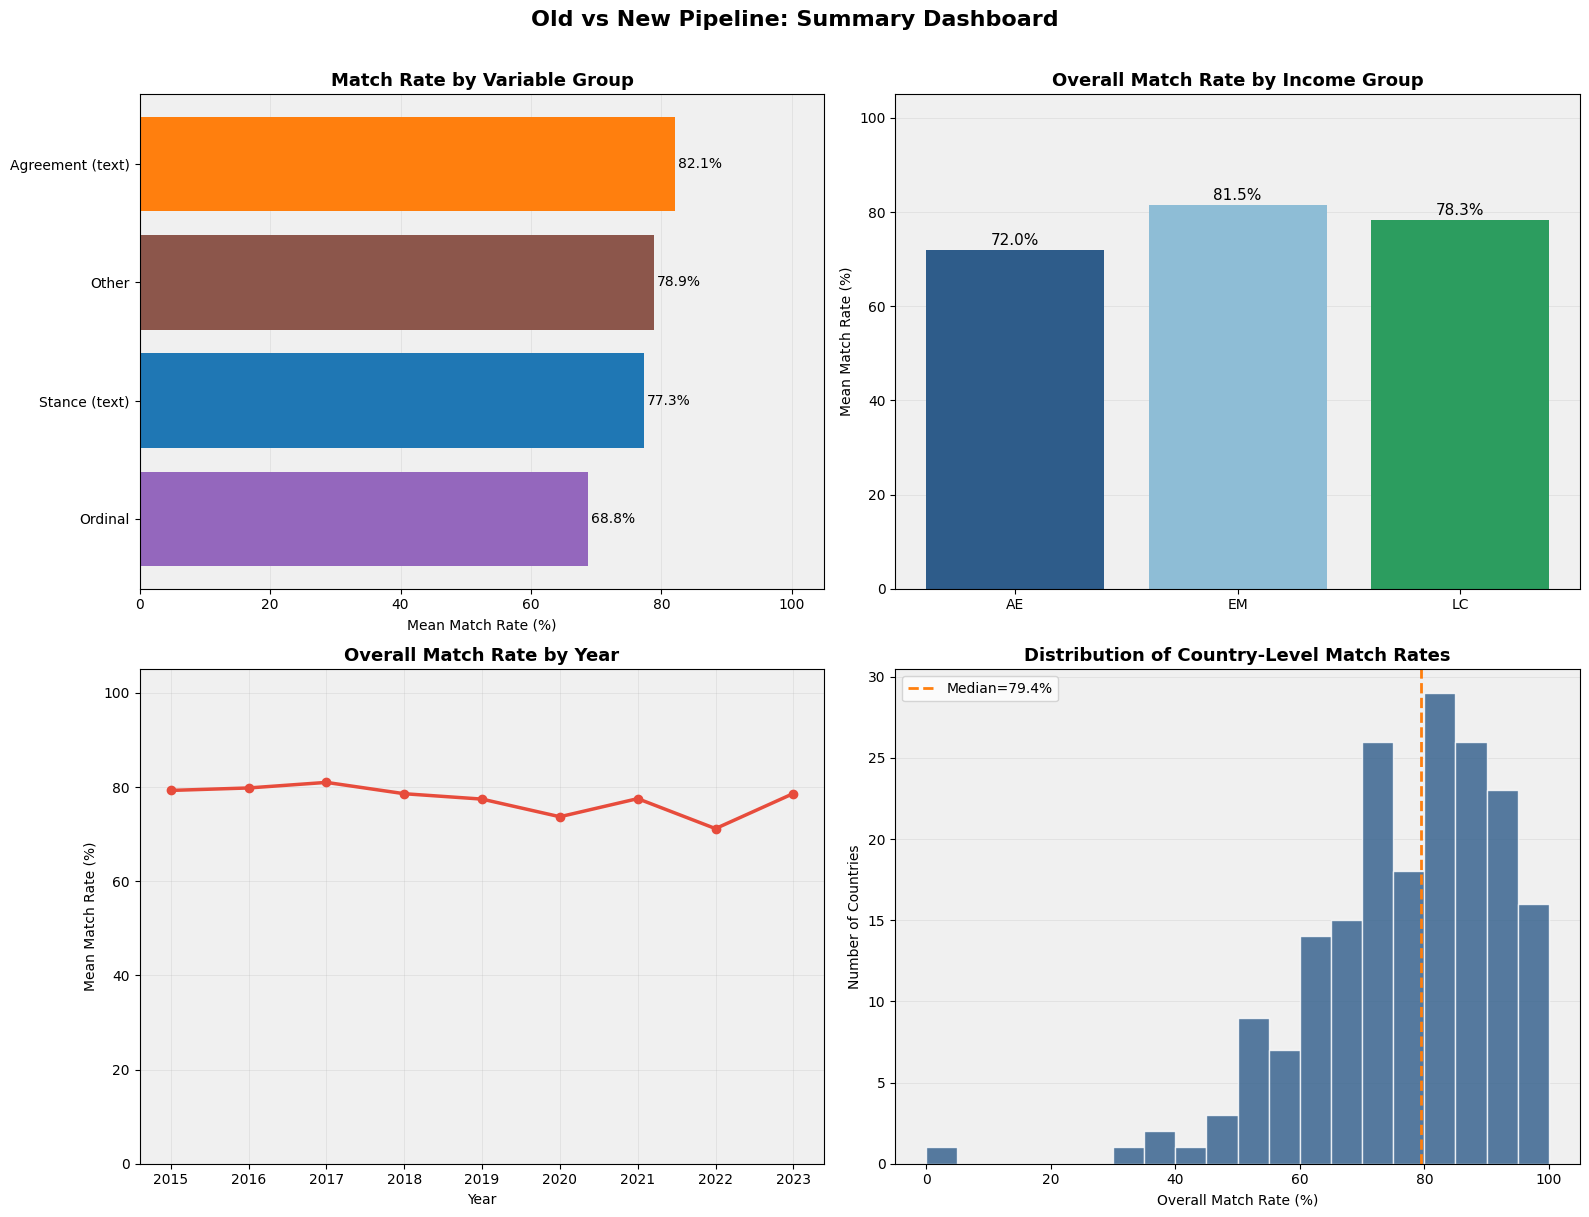

In [31]:
# ── 2x2 Summary dashboard ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (1) Overall match rates by variable group
ax = axes[0, 0]
cat_summary = df_cat_match.copy()
cat_summary["group"] = cat_summary["variable"].map(VAR_GROUP_MAP)
group_means = cat_summary.groupby("group")["match_rate"].mean().sort_values()
bars = ax.barh(group_means.index, group_means.values,
               color=[VAR_GROUP_COLORS.get(g, "#999") for g in group_means.index])
ax.set_xlabel("Mean Match Rate (%)")
ax.set_title("Match Rate by Variable Group", fontsize=13, fontweight="bold")
ax.set_xlim(0, 105)
for bar, val in zip(bars, group_means.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=10)
dv.style_axes(ax, grid=True, grid_axis="x")

# (2) Overall match rates by income group
ax = axes[0, 1]
ig_overall = []
for ig in INCOME_GROUP_ORDER:
    rates = []
    for col in key_cat_cols:
        col_old, col_new = f"{col}_old", f"{col}_new"
        if col_old not in df_merged.columns or col_new not in df_merged.columns:
            continue
        sub = df_merged[df_merged["income_group"] == ig]
        old_v = sub[col_old].astype(str).str.strip().str.lower().replace("nan", np.nan)
        new_v = sub[col_new].astype(str).str.strip().str.lower().replace("nan", np.nan)
        valid = old_v.notna() & new_v.notna()
        if valid.sum() > 0:
            rates.append((old_v[valid] == new_v[valid]).mean() * 100)
    ig_overall.append(np.mean(rates) if rates else 0)

ax.bar(INCOME_GROUP_ORDER, ig_overall,
       color=[INCOME_COLORS[g] for g in INCOME_GROUP_ORDER])
ax.set_ylabel("Mean Match Rate (%)")
ax.set_title("Overall Match Rate by Income Group", fontsize=13, fontweight="bold")
ax.set_ylim(0, 105)
for i, v in enumerate(ig_overall):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=11)
dv.style_axes(ax)

# (3) Overall match rate by year
ax = axes[1, 0]
yr_overall = []
years = sorted(df_merged["year"].dropna().unique())
for yr in years:
    rates = []
    for col in key_cat_cols:
        col_old, col_new = f"{col}_old", f"{col}_new"
        if col_old not in df_merged.columns or col_new not in df_merged.columns:
            continue
        sub = df_merged[df_merged["year"] == yr]
        old_v = sub[col_old].astype(str).str.strip().str.lower().replace("nan", np.nan)
        new_v = sub[col_new].astype(str).str.strip().str.lower().replace("nan", np.nan)
        valid = old_v.notna() & new_v.notna()
        if valid.sum() > 0:
            rates.append((old_v[valid] == new_v[valid]).mean() * 100)
    yr_overall.append(np.mean(rates) if rates else 0)

ax.plot([int(y) for y in years], yr_overall, marker="o", linewidth=2.5, color="#E74C3C")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Match Rate (%)")
ax.set_title("Overall Match Rate by Year", fontsize=13, fontweight="bold")
ax.set_ylim(0, 105)
ax.set_xticks([int(y) for y in years])
dv.style_axes(ax, grid=True, grid_axis="both")

# (4) Histogram of per-country match rates
ax = axes[1, 1]
ax.hist(df_country["overall_match%"].dropna(), bins=20, color="#2E5C8A",
        edgecolor="white", alpha=0.8)
ax.axvline(x=df_country["overall_match%"].median(), color="#FF7F0E",
           linewidth=2, linestyle="--", label=f"Median={df_country['overall_match%'].median():.1f}%")
ax.set_xlabel("Overall Match Rate (%)")
ax.set_ylabel("Number of Countries")
ax.set_title("Distribution of Country-Level Match Rates", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
dv.style_axes(ax)

plt.suptitle("Old vs New Pipeline: Summary Dashboard", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [32]:
# ── Export merged data with deviation flags ──────────────────────────────────
export_path = OUTPUT_DIR / "old_vs_new_comparison.csv"

# Add match flags for key variables
for col in key_cat_cols:
    col_old, col_new = f"{col}_old", f"{col}_new"
    if col_old in df_merged.columns and col_new in df_merged.columns:
        old_v = df_merged[col_old].astype(str).str.strip().str.lower().replace("nan", np.nan)
        new_v = df_merged[col_new].astype(str).str.strip().str.lower().replace("nan", np.nan)
        df_merged[f"{col}_match"] = (old_v == new_v) | (old_v.isna() & new_v.isna())

df_merged.to_csv(export_path, index=False)
print(f"Exported comparison data to: {export_path}")
print(f"Shape: {df_merged.shape}")

Exported comparison data to: /data/home/xiong/data/Fund/CSR/Tractions/output/old_vs_new_comparison.csv
Shape: (981, 267)
